# Library

# Diagnóstico de ensuciamiento de balasto con GPR y ML

**Objetivo.** Estimar y explicar el **Fouling Index (FI)** del balasto a partir de mediciones GPR y referencias LDCP/geoendoscopía, siguiendo la metodología del artículo. Se exploran señales en dominio temporal, su **envolvente analítica** (Hilbert) y visualizaciones por PK. :contentReference[oaicite:7]{index=7}

---

## Datos y variables clave

- `df_GPR_Dyn`: tabla principal con señales y parámetros derivados.
- **FI teórico**: `FI_T_Compacted`, `FI_T_Medium`, `FI_T_Loose` — obtenidos con ecuaciones cuadráticas por estado de compactación (Eqs. 18–20).
- **FI empírico**: `FI_E_Sands`, `FI_E_Clays` — obtenidos desde LDCP/geoendoscopía (Eqs. 8–9) con factor de corrección por tipo de finos.
- Series `ST_i_j`, `H_i_j`: matrices anchas con muestras/ventanas de señales tratadas y derivadas.

---

## Clasificación del FI (estados de balasto)

Tipología de Selig & Waters (adoptada en el paper):  
- **C (Clean)**: 0–1  
- **MC (Moderately Clean)**: 1–10  
- **MF (Moderately Fouled)**: 10–20  
- **F (Fouled)**: 20–40  
- **HF (Highly Fouled)**: >40

> **Nota:** Si se usan cortes alternativos (p. ej., 0–10 para C), dejar explícito el motivo y no mezclar con la tipología del paper.

---

## Señal analítica (Hilbert) y por qué la usamos

Aplicamos la **Transformada de Hilbert** sobre la señal tratada (con extensión en espejo para mitigar bordes) y graficamos la **envolvente**. La envolvente captura la “energía” de las reflexiones y resultó un descriptor muy informativo para el FI, según el análisis del artículo (Fig. 5e–f y discusión).

Pasos recomendados de preprocesado (según el paper): normalizar, quitar DC, eliminar onda directa, filtrar 150–800 MHz, recortar ventana de interés, BGR y, finalmente, **envolvente**.

---

## Visualizaciones

- Histograma de FI para entender su distribución.
- Perfiles por **PK** con series `ST_*`/`H_*`.  
  **Atención:** el eje temporal de GPR se expresa en **ns** (nanosegundos) cuando se muestran A-scans/tiempo, no en “horas”.

---

## Buenas prácticas en este notebook

- Documentar claramente **qué cortes de FI** se usan.  
- Reutilizar funciones para **Hilbert** y **plotting** para evitar código repetido.  
- Etiquetar ejes en **ns** o “muestras” según corresponda y anotar unidades.  
- Mantener separadas las familias **FI_T** (teórico) y **FI_E** (empírico) y comparar su coherencia con terreno.


# Tratamiento de la señal GPR (antes de calibrar el modelo)

> Objetivo: transformar los A-scans de GPR en un conjunto robusto de descriptores (tiempo, frecuencia y analíticos) que capturen variaciones asociadas al **fouling** del balasto y que sirvan de entrada a los modelos de ML. En el artículo, los grupos de parámetros y su motivación se describen con detalle y se ilustran en la Fig. 5.

---

## Nota conceptual sobre la Transformada y la envolvente de Hilbert

- Una señal GPR medida es **real**: $s(t) \in \mathbb{R}$.  
- Con esa señal sola podemos ver amplitud en el tiempo, pero no podemos definir de manera única una **fase instantánea** ni una **envolvente suave**: nos falta la "componente ortogonal".  

### ¿Qué hace la Transformada de Hilbert?
- Calcula $\hat{s}(t)$, que es la señal $s(t)$ **desfasada $90^\circ$ en todas sus frecuencias**.  
- Formalmente:
  $$
  \hat{s}(t) = \frac{1}{\pi}\,\text{p.v.} \int_{-\infty}^\infty \frac{s(\tau)}{t-\tau}\, d\tau
  $$
  (convolución con $1/(\pi t)$, donde “p.v.” indica valor principal de Cauchy).

- En el dominio de Fourier, es más fácil de entender:
  $$
  \mathcal{F}\{\hat{s}(t)\}(f) = -j \,\text{sgn}(f)\, S(f)
  $$
  Es decir, **no altera la magnitud** del espectro, solo gira la fase en $+90^\circ$ (frecuencias negativas) o $-90^\circ$ (frecuencias positivas).

### Señal analítica y envolvente
- Juntamos la señal real y su Hilbert en una señal compleja:
  $$
  a(t) = s(t) + j\,\hat{s}(t)
  $$
- Ahora sí podemos definir:
  - **Envolvente instantánea**:
    $$
    A(t) = |a(t)| = \sqrt{s(t)^2 + \hat{s}(t)^2}
    $$
  - **Fase instantánea**:
    $$
    \phi(t) = \arg(a(t))
    $$
- La envolvente $A(t)$ es lo que graficamos: una curva **suave** que “envuelve” las oscilaciones de $s(t)$ y refleja cómo evoluciona su energía en el tiempo.

### ¿Por qué mirar toda la señal?
- El desfase de 90° no se puede calcular punto a punto: depende de la **estructura global** de la señal.  
- Por eso $\hat{s}(t)$ se obtiene mediante una convolución con $1/(\pi t)$ (o, en la práctica, vía FFT en todo el vector).  
- Cada muestra de $\hat{s}(t)$ contiene información de **toda la señal original**, no solo del valor local en $t$.

---

## 0) Datos de entrada y preparación mínima
- **Fuente de datos:** `df_GPR_Dyn` (histórico de GPR y sondajes LDCP/geoendoscopía). Se trabaja a nivel de A-scan por punto de vía. El artículo describe una base con miles de km GPR y miles de sondajes emparejados.
- **Filtro posicional:** se filtra `Position == 'O'` (posición operacional definida en el dataset).
- **Limpieza:** eliminación de filas con `NaN` en *features* y *target*; reindexado para consistencia.

---

## 1) Señal tratada (ST) en el dominio del tiempo
- **Qué es:** versión procesada de la señal en tiempo para resaltar rasgos del medio granular (contrastes de capas, amplitudes más “limpias”). En la Fig. 5c–d se muestra el concepto de “treated signal”.
- **Muestreo discreto:** la señal se discretiza en una rejilla temporal uniforme (orden 0.1 ns hasta ~7 ns), generando columnas tipo `ST_i_j` que capturan el trazo en instantes fijos; este muestreo es la base de estadísticas por ventanas.
- **Salida:** un bloque de decenas de variables `ST_*` por A-scan (la figura 5 muestra el set de señales y su media).

---

## 2) Señal analítica (Hilbert) y su envolvente
- **Definición:** se calcula la **señal analítica** de $s(t)$ aplicando Transformada de Hilbert:
  
  $$a(t) \;=\; s(t) \;+\; j\,\mathcal{H}\{s(t)\}, \qquad \text{envolvente} \;=\; |a(t)|$$

  La envolvente elimina oscilaciones rápidas y concentra la información relevante para interpretación.
- **Atenuación de bordes:** para reducir artefactos de Hilbert en los extremos, se usa **acolchado espejado**: se concatena la señal invertida con la original, se aplica Hilbert y luego se **recorta** la mitad final:
  1. Construir $s_{\text{esp}} = [\,s(t)\,]$ invertida $\Vert$ $s(t)$.
  2. Calcular $a_{\text{esp}}(t) = s_{\text{esp}}(t) + j\,\mathcal{H}\{s_{\text{esp}}(t)\}$.
  3. Tomar la **envolvente** en los últimos $N$ puntos: $|a_{\text{esp}}(t)|_{N\ \text{finales}}$.
- **Salidas:**
  - **Valores de la envolvente** en instantes discretos `AH_i_j` (bloque **AH_***).
  - **Señal de Hilbert**/envolvente muestrada `H_i_j` (bloque **H_***).
  - **Área bajo la curva** de la envolvente (`area_hilbert`). En el artículo, la envolvente se destaca como pieza clave del análisis (Fig. 5e–f).

---

## 3) Dominio de la frecuencia
- **Transformada de Fourier:** se calcula el espectro para cada A-scan.
- **Descriptores derivados:**
  - **Área bajo el espectro** (`area_fourier`) y **frecuencia dominante** (`fourier_peak_max`). Este **área espectral** se ha asociado al grado de fouling: menor en balasto contaminado que en limpio (parámetro clásico en la literatura, ver Silvast y Fig. 5g–h del artículo).

---

## 4) Extracción de descriptores (feature engineering)

> La parametrización combinada (tiempo, frecuencia y analítica) se resume en la Tabla 4 del artículo y sustenta el posterior aprendizaje automático.

### 4.1) Estadísticos **globales** sobre la señal y sobre la envolvente
Se computan sobre $s(t)$ y sobre la envolvente $|a(t)|$ (sufijo `_hilbert`):
- **Momentos y cuantiles:** `mean`, `rms`, `std`, `median`, `skew`, `kurtosis`, `q1`, `q2`, `q3`, deciles `d1…d9`.
  
  $$\mathrm{RMS} = \sqrt{\frac{1}{N}\sum_{k=1}^N s_k^2},\quad
  \mathrm{skew} = \frac{\mathbb{E}[(s-\mu)^3]}{\sigma^3},\quad
  \mathrm{kurt} = \frac{\mathbb{E}[(s-\mu)^4]}{\sigma^4}$$

- **Extremos y forma:** `peak_max`, `peak_min`, `crest` (relación pico/RMS).

### 4.2) **Morfología** de la señal tratada
- `number_zeros` (cruces por cero), `points_inflexion` (cambios de concavidad), `area_signal` (integral de amplitud en tiempo).

### 4.3) **Estadística por ventanas** temporales
- División de la traza en **sub-ventanas** (rejilla temporal uniforme, orden 0.1 ns a ~7 ns) y cálculo de medias y desviaciones: `stat_slice_k_mean`, `stat_slice_k_std`. Esta granularidad establece sensibilidad local a cambios con la profundidad.

> Nota: El artículo sintetiza los **grupos** de parámetros (señales tratadas, analíticas y de frecuencia) y su **relevancia** para ML; la Fig. 5 muestra los distintos dominios y la Tabla 4 resume los contadores por grupo.

---

## 5) Construcción de matrices de características
- **Bloques crudos/muestrados:** `ST_*`, `H_*`, `AH_*` (decenas de columnas cada uno).
- **Bloques agregados:** estadísticos globales de $s(t)$ y $|a(t)|$, morfología temporal y descriptores espectrales.
- **Resultado:** un vector de **alto dimensionamiento** por A-scan (del orden de centenares de variables; en el artículo se trabaja con ~**262** parámetros agrupados por dominios).

---

## 6) Etiquetado del objetivo (solo preparación)
- A partir de los índices de fouling disponibles en el dataset (`FI_T_*` teóricos y `FI_E_*` empíricos), se generan etiquetas categóricas **`Clas_2025_*`** mediante umbrales:
  
  - $0 \le FI < 10 \Rightarrow$ **C**
  - $10 \le FI < 20 \Rightarrow$ **MC**
  - $20 \le FI < 30 \Rightarrow$ **MF**
  - $30 \le FI < 40 \Rightarrow$ **F**
  - $FI \ge 40 \Rightarrow$ **HF**
  
  Estas clases son coherentes con el uso clásico de índices de fouling en la literatura ferroviaria (e.g., Selig & Waters y variantes).

---

## 7) Control visual (QA) previo al modelado
- **Histogramas** de FI por familia (p.ej., `FI_T_Compacted`) para revisar rangos y balance.
- **Overlays** de señales `ST_*` y **envolventes** para validar el cálculo de Hilbert.
- **Trazas H/AH** por Pk específico para inspección local (consistencia temporal).

---

## 8) Justificación metodológica (resumen)
- **Envolvente de Hilbert**: concentra información física útil para diferenciar condiciones del medio granular y mejora la interpretabilidad frente a la señal oscilatoria original (Fig. 5e–f).
- **Área espectral**: indicador sensible al ensuciamiento (área menor en balasto contaminado); práctica recomendada en estudios previos (Fig. 5g–h).
- **Parametrización rica**: la combinación tiempo–frecuencia–analítica aumenta la capacidad predictiva de los modelos sobre el estado de fouling (Tabla 4 y discusión de grupos).

---

### Resultado del preprocesamiento
Se obtiene, para cada A-scan, un **vector de características multibloque** que captura:
- Amplitud y forma en **tiempo** (señal tratada).
- Información **analítica** de la **envolvente** (Hilbert).
- Energía en **frecuencia** (Fourier).
- **Estadísticos** globales y **locales** por ventanas.

Este vector es el insumo directo para la **calibración** y evaluación de modelos (RF/XGB) descrita posteriormente en el estudio.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from scipy.signal import hilbert

# Data

In [ ]:
df_GPR_Dyn = pd.read_pickle(r'D:/Investigación/Investigacion-Jorge/Data/df_GPR_Dyn.pkl')

In [ ]:
df_GPR_Dyn['Pk_Original'].unique()

array([484190, 484220, 484330, ..., 405300, 405420, 405600], dtype=int64)

In [ ]:
columnas = df_GPR_Dyn.columns.tolist()
columnas

['N',
 'Date',
 'Km',
 'Position',
 'Distance_Axe',
 'CT',
 'Prof_BS',
 'qd_BS',
 'Prof_BC',
 'qd_BC',
 'Nature_Colmatage',
 'Prof_CI',
 'qd_CI',
 'Nature_CI',
 'Prof_SS',
 'qd_SS',
 'Nature_SS',
 'Tipo_Cordenada',
 'Est',
 'Nord',
 'Altitud',
 'Referencia_Chantier',
 'Voie',
 'Pk',
 'Pk_Original',
 'Eje',
 'mean',
 'rms',
 'ecart_type',
 'median',
 'skew',
 'kurtosis',
 'q1',
 'q2',
 'q3',
 'd1',
 'd2',
 'd3',
 'd4',
 'd6',
 'd7',
 'd8',
 'd9',
 'peak_max',
 'peak_min',
 'crest',
 'area_hilbert',
 'mean_hilbert',
 'rms_hilbert',
 'std_hilbert',
 'median_hilbert',
 'skew_hilbert',
 'kurtosis_hilbert',
 'q1_hilbert',
 'q2_hilbert',
 'q3_hilbert',
 'd1_hilbert',
 'd2_hilbert',
 'd3_hilbert',
 'd4_hilbert',
 'd6_hilbert',
 'd7_hilbert',
 'd8_hilbert',
 'd9_hilbert',
 'peak_max_hilbert',
 'peak_min_hilbert',
 'crest_hilbert',
 'number_zeros',
 'area_signal',
 'points_inflexion',
 'area_fourier',
 'fourier_peak_max',
 'Chantier_x',
 'Ligne_x',
 'Voie_x',
 'Chantier_y',
 'Ligne_y',
 'Voie_y'

In [ ]:
df_GPR_Dyn['FI_T_Medium']

0         11.627402
1         11.627402
2         11.627402
3         11.627402
4         11.627402
            ...    
134961    15.208300
134962    15.208300
134963    15.208300
134964    15.208300
134965    15.208300
Name: FI_T_Medium, Length: 134966, dtype: float64

In [ ]:
columnas = [
    'Clasification_Clasica_Compacted',
    'Clasification_Clasica_Medium',
    'Clasification_Clasica_Loose'
]

for columna in columnas:
    print(f"Frecuencia de valores en la columna '{columna}':")
    print(df_GPR_Dyn[columna].value_counts())
    print()

Frecuencia de valores en la columna 'Clasification_Clasica_Compacted':
Clasification_Clasica_Compacted
F     58892
MF    51639
C     13464
HF     6466
MC     4505
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clasification_Clasica_Medium':
Clasification_Clasica_Medium
F     71837
MF    39970
C     13464
HF     7181
MC     2514
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clasification_Clasica_Loose':
Clasification_Clasica_Loose
F     79882
MF    28340
C     13464
HF    11965
MC     1315
Name: count, dtype: int64



In [ ]:
def clasificar_filas(valor):
    if 0 <= valor <= 10:
        return 'C'
    elif 10 <= valor < 20:
        return 'MC'
    elif 20 <= valor < 30:
        return 'MF'
    elif 30 <= valor < 40:
        return 'F'
    elif valor >= 40:
        return 'HF'
    else:
        return 'Fuera de rango'

# Lista de las columnas a analizar y crear nuevas columnas
columnas_analisis = ['FI_T_Compacted', 'FI_T_Medium', 'FI_T_Loose', 'FI_E_Sands', 'FI_E_Clays']

for columna in columnas_analisis:
    # Nombre de la nueva columna
    nueva_columna = f'Clas_2025_{columna}'

    df_GPR_Dyn[nueva_columna] = df_GPR_Dyn[columna].apply(clasificar_filas)

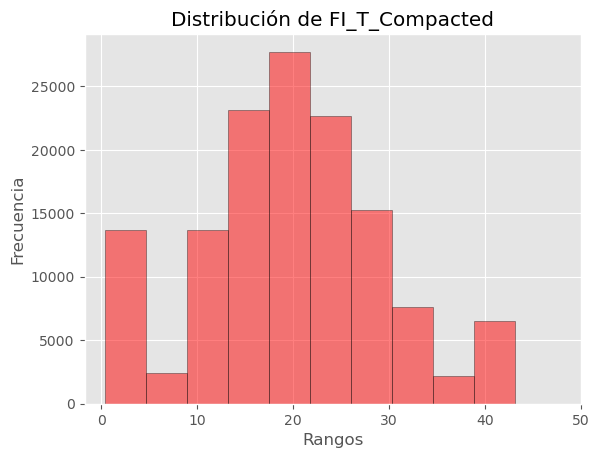

In [ ]:
# Crear un histograma
# plt.hist(df_GPR_Dyn['FI_T_Compacted'], bins=[0, 10, 20, 30, 40, 50], edgecolor='black', color ='red', alpha = 0.5, label = "Compacted")
# plt.hist(df_GPR_Dyn['FI_T_Medium'], bins=[0, 10, 20, 30, 40, 50], edgecolor='black', color ='blue', alpha = 0.5, label = "Medium")
# plt.hist(df_GPR_Dyn['FI_T_Loose'], bins=[0, 10, 20, 30, 40, 50], edgecolor='black', color ='yellow', alpha = 0.5, label = "Loose")

plt.hist(df_GPR_Dyn['FI_T_Compacted'], edgecolor='black', color ='red', alpha = 0.5, label = "Compacted")
# plt.hist(df_GPR_Dyn['FI_T_Medium'], edgecolor='black', color ='blue', alpha = 0.5, label = "Medium")
# plt.hist(df_GPR_Dyn['FI_T_Loose'], edgecolor='black', color ='yellow', alpha = 0.5, label = "Loose")

plt.title('Distribución de FI_T_Compacted')
plt.xlabel('Rangos')
plt.ylabel('Frecuencia')
plt.xticks([0, 10, 20, 30, 40, 50])
plt.show()

In [ ]:
columnas = [
    'Clas_2025_FI_T_Compacted',
    'Clas_2025_FI_T_Medium',
    'Clas_2025_FI_T_Loose',
    'Clas_2025_FI_E_Sands',
    'Clas_2025_FI_E_Clays'
]

for columna in columnas:
    print(f"Frecuencia de valores en la columna '{columna}':")
    print(df_GPR_Dyn[columna].value_counts())
    print()

Frecuencia de valores en la columna 'Clas_2025_FI_T_Compacted':
Clas_2025_FI_T_Compacted
MC    51639
MF    48224
C     17969
F     10668
HF     6466
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clas_2025_FI_T_Medium':
Clas_2025_FI_T_Medium
MF    52149
MC    39970
F     19688
C     15978
HF     7181
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clas_2025_FI_T_Loose':
Clas_2025_FI_T_Loose
MF    49441
F     30441
MC    28340
C     14779
HF    11965
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clas_2025_FI_E_Sands':
Clas_2025_FI_E_Sands
MC    51704
MF    42711
C     20964
F     12406
HF     7181
Name: count, dtype: int64

Frecuencia de valores en la columna 'Clas_2025_FI_E_Clays':
Clas_2025_FI_E_Clays
MF    42228
MC    29374
F     28272
HF    19587
C     15505
Name: count, dtype: int64



In [ ]:
df_GPR_Dyn

,N,Date,Km,Position,Distance_Axe,CT,Prof_BS,qd_BS,Prof_BC,qd_BC,...,Clasification_Clasica_Compacted,Clasification_Clasica_Medium,Clasification_Clasica_Loose,FI_E_Sands,FI_E_Clays,Clas_2025_FI_T_Compacted,Clas_2025_FI_T_Medium,Clas_2025_FI_T_Loose,Clas_2025_FI_E_Sands,Clas_2025_FI_E_Clays
0,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,MF,MF,MF,9.285714,12.380952,MC,MC,MC,C,MC
1,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,MF,MF,MF,9.285714,12.380952,MC,MC,MC,C,MC
2,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,MF,MF,MF,9.285714,12.380952,MC,MC,MC,C,MC
3,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,MF,MF,MF,9.285714,12.380952,MC,MC,MC,C,MC
4,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,MF,MF,MF,9.285714,12.380952,MC,MC,MC,C,MC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134961,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,MF,MF,MF,12.500000,16.666667,MC,MC,MC,MC,MC
134962,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,MF,MF,MF,12.500000,16.666667,MC,MC,MC,MC,MC
134963,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,MF,MF,MF,12.500000,16.666667,MC,MC,MC,MC,MC
134964,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,MF,MF,MF,12.500000,16.666667,MC,MC,MC,MC,MC


In [ ]:
df_GPR_Dyn_Pk = df_GPR_Dyn[df_GPR_Dyn['Pk_Original'] == 405300]
df_GPR_Dyn_Pk = df_GPR_Dyn_Pk.reset_index(drop=True)

In [ ]:
col_st = [
    'ST_0_0', 'ST_0_1', 'ST_0_2', 'ST_0_4', 'ST_0_5', 'ST_0_8', 'ST_0_9',
    'ST_1_0', 'ST_1_1', 'ST_1_2', 'ST_1_3', 'ST_1_4', 'ST_1_5', 'ST_1_6', 'ST_1_8', 'ST_1_9',
    'ST_2_0', 'ST_2_1', 'ST_2_2', 'ST_2_3', 'ST_2_4', 'ST_2_5', 'ST_2_6', 'ST_2_7', 'ST_2_8', 'ST_2_9',
    'ST_3_0', 'ST_3_1', 'ST_3_2', 'ST_3_3', 'ST_3_4', 'ST_3_5', 'ST_3_6', 'ST_3_7', 'ST_3_8', 'ST_3_9',
    'ST_4_0', 'ST_4_1', 'ST_4_2', 'ST_4_3', 'ST_4_4', 'ST_4_5', 'ST_4_6', 'ST_4_7', 'ST_4_8', 'ST_4_9',
    'ST_5_0', 'ST_5_1', 'ST_5_2', 'ST_5_3', 'ST_5_4', 'ST_5_5', 'ST_5_6', 'ST_5_7', 'ST_5_8', 'ST_5_9',
    'ST_6_0', 'ST_6_1', 'ST_6_2', 'ST_6_3', 'ST_6_4', 'ST_6_5', 'ST_6_6', 'ST_6_7', 'ST_6_8', 'ST_6_9',
    'ST_7_0', 'ST_7_1', 'ST_7_2', 'ST_7_3', 'ST_7_4', 'ST_7_5', 'ST_7_6', 'ST_7_7', 'ST_7_8', 'ST_7_9',
    'ST_8_0', 'ST_8_1', 'ST_8_2', 'ST_8_3', 'ST_8_4', 'ST_8_5', 'ST_8_6', 'ST_8_7', 'ST_8_8', 'ST_8_9',
    'ST_9_0', 'ST_9_1', 'ST_9_2', 'ST_9_3', 'ST_9_4', 'ST_9_5', 'ST_9_6', 'ST_9_7', 'ST_9_8', 'ST_9_9',
    'ST_10_0', 'ST_10_1', 'ST_10_2', 'ST_10_3', 'ST_10_4', 'ST_10_5', 'ST_10_6', 'ST_10_7', 'ST_10_8', 'ST_10_9',
    'ST_11_0', 'ST_11_1', 'ST_11_2', 'ST_11_3', 'ST_11_4', 'ST_11_5', 'ST_11_6', 'ST_11_7', 'ST_11_8', 'ST_11_9',
    'ST_12_0', 'ST_12_1', 'ST_12_2', 'ST_12_3', 'ST_12_4', 'ST_12_5', 'ST_12_6', 'ST_12_7', 'ST_12_8', 'ST_12_9',
    'ST_13_0', 'ST_13_1', 'ST_13_2', 'ST_13_3', 'ST_13_4', 'ST_13_5', 'ST_13_6', 'ST_13_7', 'ST_13_8', 'ST_13_9',
    'ST_14_0', 'ST_14_1', 'ST_14_2', 'ST_14_3', 'ST_14_4', 'ST_14_5', 'ST_14_6', 'ST_14_7', 'ST_14_8', 'ST_14_9',
    'ST_15_0', 'ST_15_1', 'ST_15_2', 'ST_15_3', 'ST_15_4', 'ST_15_5', 'ST_15_6', 'ST_15_7', 'ST_15_8', 'ST_15_9'
]

In [ ]:
st_original = df_GPR_Dyn.loc[0, col_st].to_numpy()
st_espejo = np.concatenate((st_original[::-1], st_original))
analytic_signal = hilbert(st_espejo)
amplitude_envelope= np.abs(analytic_signal[len(st_original):])

st_original2 = df_GPR_Dyn.loc[2, col_st].to_numpy()
st_espejo2 = np.concatenate((st_original2[::-1], st_original2))
analytic_signal2 = hilbert(st_espejo2)
amplitude_envelope2= np.abs(analytic_signal2[len(st_original2):])

st_original3 = df_GPR_Dyn.loc[3, col_st].to_numpy()
st_espejo3 = np.concatenate((st_original3[::-1], st_original3))
analytic_signal3 = hilbert(st_espejo3)
amplitude_envelope3= np.abs(analytic_signal3[len(st_original3):])

st_original4 = df_GPR_Dyn.loc[4, col_st].to_numpy()
st_espejo4 = np.concatenate((st_original4[::-1], st_original4))
analytic_signal4 = hilbert(st_espejo4)
amplitude_envelope4= np.abs(analytic_signal4[len(st_original4):])

st_original5 = df_GPR_Dyn.loc[5, col_st].to_numpy()
st_espejo5 = np.concatenate((st_original5[::-1], st_original5))
analytic_signal5 = hilbert(st_espejo5)
amplitude_envelope5= np.abs(analytic_signal5[len(st_original5):])

st_original6 = df_GPR_Dyn.loc[6, col_st].to_numpy()
st_espejo6 = np.concatenate((st_original6[::-1], st_original6))
analytic_signal6 = hilbert(st_espejo6)
amplitude_envelope6= np.abs(analytic_signal6[len(st_original6):])

st_original7 = df_GPR_Dyn.loc[7, col_st].to_numpy()
st_espejo7 = np.concatenate((st_original7[::-1], st_original7))
analytic_signal7 = hilbert(st_espejo7)
amplitude_envelope7= np.abs(analytic_signal7[len(st_original7):])

st_original8 = df_GPR_Dyn.loc[8, col_st].to_numpy()
st_espejo8 = np.concatenate((st_original8[::-1], st_original8))
analytic_signal8 = hilbert(st_espejo8)
amplitude_envelope8= np.abs(analytic_signal8[len(st_original8):])

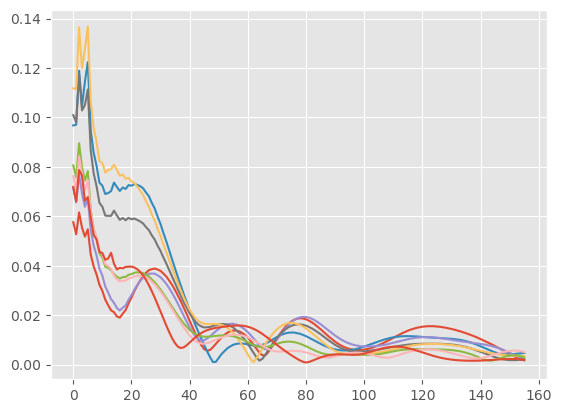

In [ ]:
plt.plot(amplitude_envelope)
plt.plot(amplitude_envelope2)
plt.plot(amplitude_envelope3)
plt.plot(amplitude_envelope4)
plt.plot(amplitude_envelope5)
plt.plot(amplitude_envelope6)
plt.plot(amplitude_envelope7)
plt.plot(amplitude_envelope8)

In [ ]:
st_original = df_GPR_Dyn.loc[0, col_st].to_numpy()
st_espejo = np.concatenate((st_original[::-1], st_original))
analytic_signal = hilbert(st_espejo)
amplitude_envelope= np.abs(analytic_signal[len(st_original):])

st_original2 = df_GPR_Dyn.loc[2, col_st].to_numpy()
st_espejo2 = np.concatenate((st_original2[::-1], st_original2))
analytic_signal2 = hilbert(st_espejo2)
amplitude_envelope2= np.abs(analytic_signal2[len(st_original2):])

st_original3 = df_GPR_Dyn.loc[3, col_st].to_numpy()
st_espejo3 = np.concatenate((st_original3[::-1], st_original3))
analytic_signal3 = hilbert(st_espejo3)
amplitude_envelope3= np.abs(analytic_signal3[len(st_original3):])

st_original4 = df_GPR_Dyn.loc[4, col_st].to_numpy()
st_espejo4 = np.concatenate((st_original4[::-1], st_original4))
analytic_signal4 = hilbert(st_espejo4)
amplitude_envelope4= np.abs(analytic_signal4[len(st_original4):])

st_original5 = df_GPR_Dyn.loc[5, col_st].to_numpy()
st_espejo5 = np.concatenate((st_original5[::-1], st_original5))
analytic_signal5 = hilbert(st_espejo5)
amplitude_envelope5= np.abs(analytic_signal5[len(st_original5):])

st_original6 = df_GPR_Dyn.loc[6, col_st].to_numpy()
st_espejo6 = np.concatenate((st_original6[::-1], st_original6))
analytic_signal6 = hilbert(st_espejo6)
amplitude_envelope6= np.abs(analytic_signal6[len(st_original6):])

st_original7 = df_GPR_Dyn.loc[7, col_st].to_numpy()
st_espejo7 = np.concatenate((st_original7[::-1], st_original7))
analytic_signal7 = hilbert(st_espejo7)
amplitude_envelope7= np.abs(analytic_signal7[len(st_original7):])

st_original8 = df_GPR_Dyn.loc[8, col_st].to_numpy()
st_espejo8 = np.concatenate((st_original8[::-1], st_original8))
analytic_signal8 = hilbert(st_espejo8)
amplitude_envelope8= np.abs(analytic_signal8[len(st_original8):])

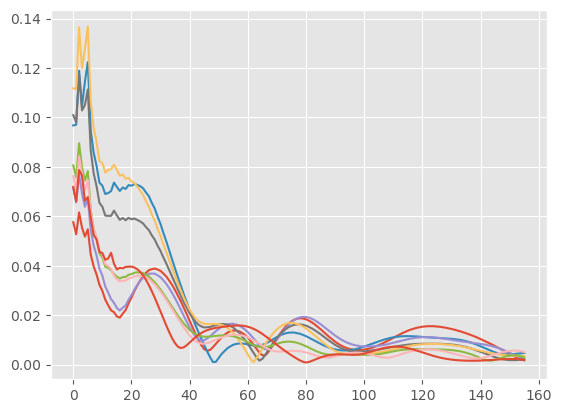

In [ ]:
plt.plot(amplitude_envelope)
plt.plot(amplitude_envelope2)
plt.plot(amplitude_envelope3)
plt.plot(amplitude_envelope4)
plt.plot(amplitude_envelope5)
plt.plot(amplitude_envelope6)
plt.plot(amplitude_envelope7)
plt.plot(amplitude_envelope8)

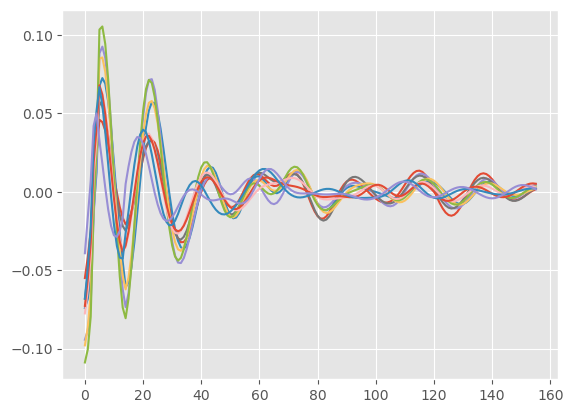

In [ ]:
plt.plot(df_GPR_Dyn.loc[0, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[1, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[2, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[3, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[4, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[5, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[6, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[7, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[8, col_st].to_numpy())
plt.plot(df_GPR_Dyn.loc[9, col_st].to_numpy())

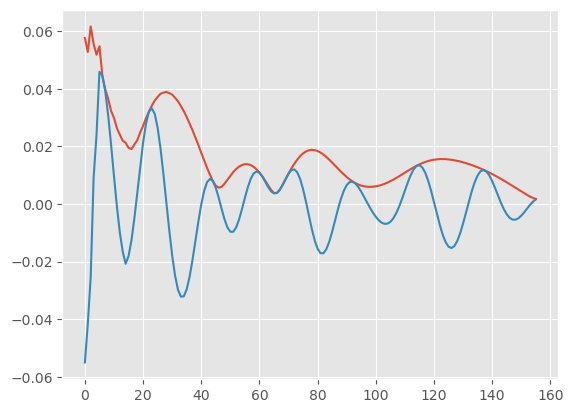

In [ ]:
plt.plot(amplitude_envelope)
plt.plot(df_GPR_Dyn.loc[0, col_st].to_numpy())

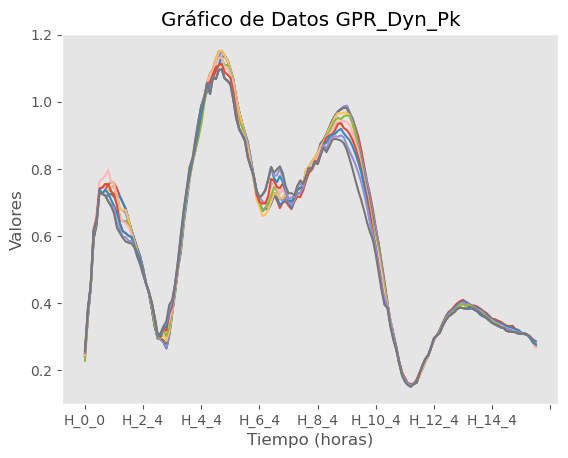

In [ ]:
columns_to_use = [
    'H_0_0', 'H_0_1', 'H_0_2', 'H_0_4', 'H_0_5', 'H_0_8', 'H_0_9',
    'H_1_0', 'H_1_1', 'H_1_2', 'H_1_3', 'H_1_4', 'H_1_5', 'H_1_6', 'H_1_8', 'H_1_9',
    'H_2_0', 'H_2_1', 'H_2_2', 'H_2_3', 'H_2_4', 'H_2_5', 'H_2_6', 'H_2_7', 'H_2_8', 'H_2_9',
    'H_3_0', 'H_3_1', 'H_3_2', 'H_3_3', 'H_3_4', 'H_3_5', 'H_3_6', 'H_3_7', 'H_3_8', 'H_3_9',
    'H_4_0', 'H_4_1', 'H_4_2', 'H_4_3', 'H_4_4', 'H_4_5', 'H_4_6', 'H_4_7', 'H_4_8', 'H_4_9',
    'H_5_0', 'H_5_1', 'H_5_2', 'H_5_3', 'H_5_4', 'H_5_5', 'H_5_6', 'H_5_7', 'H_5_8', 'H_5_9',
    'H_6_0', 'H_6_1', 'H_6_2', 'H_6_3', 'H_6_4', 'H_6_5', 'H_6_6', 'H_6_7', 'H_6_8', 'H_6_9',
    'H_7_0', 'H_7_1', 'H_7_2', 'H_7_3', 'H_7_4', 'H_7_5', 'H_7_6', 'H_7_7', 'H_7_8', 'H_7_9',
    'H_8_0', 'H_8_1', 'H_8_2', 'H_8_3', 'H_8_4', 'H_8_5', 'H_8_6', 'H_8_7', 'H_8_8', 'H_8_9',
    'H_9_0', 'H_9_1', 'H_9_2', 'H_9_3', 'H_9_4', 'H_9_5', 'H_9_6', 'H_9_7', 'H_9_8', 'H_9_9',
    'H_10_0', 'H_10_1', 'H_10_2', 'H_10_3', 'H_10_4', 'H_10_5', 'H_10_6', 'H_10_7', 'H_10_8', 'H_10_9',
    'H_11_0', 'H_11_1', 'H_11_2', 'H_11_3', 'H_11_4', 'H_11_5', 'H_11_6', 'H_11_7', 'H_11_8', 'H_11_9',
    'H_12_0', 'H_12_1', 'H_12_2', 'H_12_3', 'H_12_4', 'H_12_5', 'H_12_6', 'H_12_7', 'H_12_8', 'H_12_9',
    'H_13_0', 'H_13_1', 'H_13_2', 'H_13_3', 'H_13_4', 'H_13_5', 'H_13_6', 'H_13_7', 'H_13_8', 'H_13_9',
    'H_14_0', 'H_14_1', 'H_14_2', 'H_14_3', 'H_14_4', 'H_14_5', 'H_14_6', 'H_14_7', 'H_14_8', 'H_14_9',
    'H_15_0', 'H_15_1', 'H_15_2', 'H_15_3', 'H_15_4', 'H_15_5', 'H_15_6', 'H_15_7', 'H_15_8', 'H_15_9'
]

# Crear el eje x de valores
x_values = [i + j / 10 for i in range(16) for j in range(10) if f'H_{i}_{j}' in columns_to_use]

# Cargar datos
# df_GPR_Dyn_Pk = pd.read_csv('data.csv')  # Cargar el DataFrame desde un archivo si es necesario

df_selected = df_GPR_Dyn_Pk[columns_to_use]

# Graficar cada fila como una línea
df_selected.T.plot(legend=False)
# plt.xticks(range(len(x_values)), x_values, rotation=90)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Valores")
plt.title("Gráfico de Datos GPR_Dyn_Pk")
plt.grid()
plt.show()

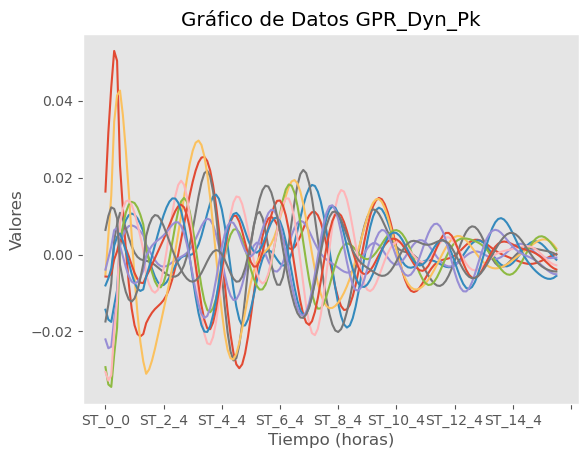

In [ ]:
columns_to_use = [
    'ST_0_0', 'ST_0_1', 'ST_0_2', 'ST_0_4', 'ST_0_5', 'ST_0_8', 'ST_0_9',
    'ST_1_0', 'ST_1_1', 'ST_1_2', 'ST_1_3', 'ST_1_4', 'ST_1_5', 'ST_1_6', 'ST_1_8', 'ST_1_9',
    'ST_2_0', 'ST_2_1', 'ST_2_2', 'ST_2_3', 'ST_2_4', 'ST_2_5', 'ST_2_6', 'ST_2_7', 'ST_2_8', 'ST_2_9',
    'ST_3_0', 'ST_3_1', 'ST_3_2', 'ST_3_3', 'ST_3_4', 'ST_3_5', 'ST_3_6', 'ST_3_7', 'ST_3_8', 'ST_3_9',
    'ST_4_0', 'ST_4_1', 'ST_4_2', 'ST_4_3', 'ST_4_4', 'ST_4_5', 'ST_4_6', 'ST_4_7', 'ST_4_8', 'ST_4_9',
    'ST_5_0', 'ST_5_1', 'ST_5_2', 'ST_5_3', 'ST_5_4', 'ST_5_5', 'ST_5_6', 'ST_5_7', 'ST_5_8', 'ST_5_9',
    'ST_6_0', 'ST_6_1', 'ST_6_2', 'ST_6_3', 'ST_6_4', 'ST_6_5', 'ST_6_6', 'ST_6_7', 'ST_6_8', 'ST_6_9',
    'ST_7_0', 'ST_7_1', 'ST_7_2', 'ST_7_3', 'ST_7_4', 'ST_7_5', 'ST_7_6', 'ST_7_7', 'ST_7_8', 'ST_7_9',
    'ST_8_0', 'ST_8_1', 'ST_8_2', 'ST_8_3', 'ST_8_4', 'ST_8_5', 'ST_8_6', 'ST_8_7', 'ST_8_8', 'ST_8_9',
    'ST_9_0', 'ST_9_1', 'ST_9_2', 'ST_9_3', 'ST_9_4', 'ST_9_5', 'ST_9_6', 'ST_9_7', 'ST_9_8', 'ST_9_9',
    'ST_10_0', 'ST_10_1', 'ST_10_2', 'ST_10_3', 'ST_10_4', 'ST_10_5', 'ST_10_6', 'ST_10_7', 'ST_10_8', 'ST_10_9',
    'ST_11_0', 'ST_11_1', 'ST_11_2', 'ST_11_3', 'ST_11_4', 'ST_11_5', 'ST_11_6', 'ST_11_7', 'ST_11_8', 'ST_11_9',
    'ST_12_0', 'ST_12_1', 'ST_12_2', 'ST_12_3', 'ST_12_4', 'ST_12_5', 'ST_12_6', 'ST_12_7', 'ST_12_8', 'ST_12_9',
    'ST_13_0', 'ST_13_1', 'ST_13_2', 'ST_13_3', 'ST_13_4', 'ST_13_5', 'ST_13_6', 'ST_13_7', 'ST_13_8', 'ST_13_9',
    'ST_14_0', 'ST_14_1', 'ST_14_2', 'ST_14_3', 'ST_14_4', 'ST_14_5', 'ST_14_6', 'ST_14_7', 'ST_14_8', 'ST_14_9',
    'ST_15_0', 'ST_15_1', 'ST_15_2', 'ST_15_3', 'ST_15_4', 'ST_15_5', 'ST_15_6', 'ST_15_7', 'ST_15_8', 'ST_15_9'
]


# Crear el eje x de valores
x_values = [i + j / 10 for i in range(16) for j in range(10) if f'H_{i}_{j}' in columns_to_use]

# Cargar datos
# df_GPR_Dyn_Pk = pd.read_csv('data.csv')  # Cargar el DataFrame desde un archivo si es necesario

df_selected = df_GPR_Dyn_Pk[columns_to_use]

# Graficar cada fila como una línea
df_selected.T.plot(legend=False)
# plt.xticks(range(len(x_values)), x_values, rotation=90)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Valores")
plt.title("Gráfico de Datos GPR_Dyn_Pk")
plt.grid()
plt.show()

In [ ]:
# df_GPR_Dyn_Pk[columns_to_use] = df_GPR_Dyn_Pk[columns_to_use].abs()

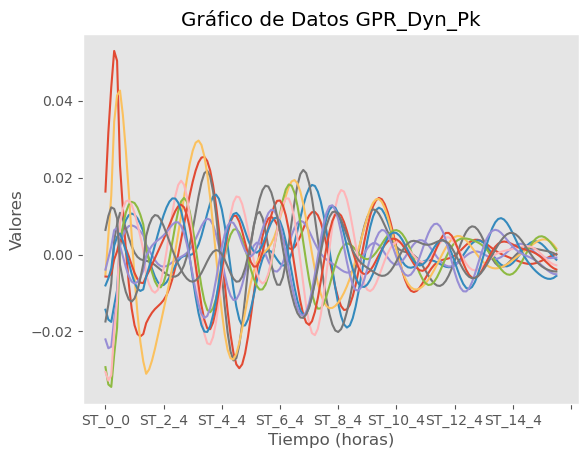

In [ ]:
columns_to_use = [
    'ST_0_0', 'ST_0_1', 'ST_0_2', 'ST_0_4', 'ST_0_5', 'ST_0_8', 'ST_0_9',
    'ST_1_0', 'ST_1_1', 'ST_1_2', 'ST_1_3', 'ST_1_4', 'ST_1_5', 'ST_1_6', 'ST_1_8', 'ST_1_9',
    'ST_2_0', 'ST_2_1', 'ST_2_2', 'ST_2_3', 'ST_2_4', 'ST_2_5', 'ST_2_6', 'ST_2_7', 'ST_2_8', 'ST_2_9',
    'ST_3_0', 'ST_3_1', 'ST_3_2', 'ST_3_3', 'ST_3_4', 'ST_3_5', 'ST_3_6', 'ST_3_7', 'ST_3_8', 'ST_3_9',
    'ST_4_0', 'ST_4_1', 'ST_4_2', 'ST_4_3', 'ST_4_4', 'ST_4_5', 'ST_4_6', 'ST_4_7', 'ST_4_8', 'ST_4_9',
    'ST_5_0', 'ST_5_1', 'ST_5_2', 'ST_5_3', 'ST_5_4', 'ST_5_5', 'ST_5_6', 'ST_5_7', 'ST_5_8', 'ST_5_9',
    'ST_6_0', 'ST_6_1', 'ST_6_2', 'ST_6_3', 'ST_6_4', 'ST_6_5', 'ST_6_6', 'ST_6_7', 'ST_6_8', 'ST_6_9',
    'ST_7_0', 'ST_7_1', 'ST_7_2', 'ST_7_3', 'ST_7_4', 'ST_7_5', 'ST_7_6', 'ST_7_7', 'ST_7_8', 'ST_7_9',
    'ST_8_0', 'ST_8_1', 'ST_8_2', 'ST_8_3', 'ST_8_4', 'ST_8_5', 'ST_8_6', 'ST_8_7', 'ST_8_8', 'ST_8_9',
    'ST_9_0', 'ST_9_1', 'ST_9_2', 'ST_9_3', 'ST_9_4', 'ST_9_5', 'ST_9_6', 'ST_9_7', 'ST_9_8', 'ST_9_9',
    'ST_10_0', 'ST_10_1', 'ST_10_2', 'ST_10_3', 'ST_10_4', 'ST_10_5', 'ST_10_6', 'ST_10_7', 'ST_10_8', 'ST_10_9',
    'ST_11_0', 'ST_11_1', 'ST_11_2', 'ST_11_3', 'ST_11_4', 'ST_11_5', 'ST_11_6', 'ST_11_7', 'ST_11_8', 'ST_11_9',
    'ST_12_0', 'ST_12_1', 'ST_12_2', 'ST_12_3', 'ST_12_4', 'ST_12_5', 'ST_12_6', 'ST_12_7', 'ST_12_8', 'ST_12_9',
    'ST_13_0', 'ST_13_1', 'ST_13_2', 'ST_13_3', 'ST_13_4', 'ST_13_5', 'ST_13_6', 'ST_13_7', 'ST_13_8', 'ST_13_9',
    'ST_14_0', 'ST_14_1', 'ST_14_2', 'ST_14_3', 'ST_14_4', 'ST_14_5', 'ST_14_6', 'ST_14_7', 'ST_14_8', 'ST_14_9',
    'ST_15_0', 'ST_15_1', 'ST_15_2', 'ST_15_3', 'ST_15_4', 'ST_15_5', 'ST_15_6', 'ST_15_7', 'ST_15_8', 'ST_15_9'
]

# Crear el eje x de valores
x_values = [i + j / 10 for i in range(16) for j in range(10) if f'H_{i}_{j}' in columns_to_use]

# Cargar datos
# df_GPR_Dyn_Pk = pd.read_csv('data.csv')  # Cargar el DataFrame desde un archivo si es necesario

df_selected = df_GPR_Dyn_Pk[columns_to_use]

# Graficar cada fila como una línea
df_selected.T.plot(legend=False)
# plt.xticks(range(len(x_values)), x_values, rotation=90)
plt.xlabel("Tiempo (horas)")
plt.ylabel("Valores")
plt.title("Gráfico de Datos GPR_Dyn_Pk")
plt.grid()
plt.show()

## Recalculo Hilbert

# Dataset entregado al Random Forest

Cada A-scan de GPR se transforma en un **vector de características** que mezcla tres dominios: **tiempo, frecuencia y analítico (Hilbert)**.  
Lo importante es distinguir entre **descriptores globales** (sobre toda la señal) y **descriptores locales** (calculados en sub-ventanas).

---

## 1. Señal tratada (ST) – Dominio temporal

- **Entrada:** traza $s(t)$, discretizada en $N$ muestras.
- **Salidas:**
  - Columnas discretas `ST_i_j` (valores de $s(t)$ en cada punto).
  - **Estadísticos globales (sobre toda la señal):**

    $$
    \text{mean} = \frac{1}{N}\sum_{k=1}^N s_k
    $$
    $$
    \text{RMS} = \sqrt{\frac{1}{N}\sum_{k=1}^N s_k^2}
    $$
    $$
    \text{skew} = \frac{\mathbb{E}[(s-\mu)^3]}{\sigma^3}, \quad
    \text{kurt} = \frac{\mathbb{E}[(s-\mu)^4]}{\sigma^4}
    $$

  - **Morfología global:**
    - `number_zeros`: número total de cruces por cero en la traza.
    - `points_inflexion`: puntos donde cambia la curvatura.
    - `area_signal = \sum |s_k|\Delta t` (área total bajo la señal).

---

## 2. Transformada de Hilbert – Señal analítica

- **Definición:**
  $$
  a(t) = s(t) + j \hat{s}(t), \quad
  A(t) = |a(t)| = \sqrt{s(t)^2 + \hat{s}(t)^2}
  $$

- **Salidas:**
  - Columnas discretas `H_i_j` (parte imaginaria de Hilbert).
  - Columnas `AH_i_j` (envolvente $A(t)$).
  - **Estadísticos globales sobre la envolvente:**  
    `mean_hilbert`, `rms_hilbert`, `std_hilbert`, `area_hilbert = \sum A_k \Delta t`.

---

## 3. Transformada de Fourier – Dominio de frecuencia

- **Definición:**
  $$
  S(f) = \sum_{k=1}^N s_k \, e^{-j 2\pi f t_k}
  $$

- **Descriptores globales (sobre todo el espectro):**
  - Área espectral:  
    $$
    \text{area\_fourier} = \sum_f |S(f)|
    $$
  - Pico espectral máximo:  
    $$
    \text{fourier\_peak\_max} = \max_f |S(f)|
    $$

---

## 4. Estadística por ventanas (sub-ventanas locales)

- **Motivación:** capturar variaciones internas a lo largo de la profundidad/tiempo.  
- **Procedimiento:**
  - Se divide la traza en $M$ ventanas $w_m$ de igual duración (ej. 0.1 ns).
  - En cada ventana se calculan métricas locales:

    $$
    \text{stat\_slice\_m\_mean} = \frac{1}{|w_m|}\sum_{k\in w_m} s_k
    $$

    $$
    \text{stat\_slice\_m\_std} = \sqrt{\frac{1}{|w_m|}\sum_{k\in w_m}(s_k-\mu_m)^2}
    $$

- **Salida:** columnas `stat_slice_k_mean`, `stat_slice_k_std` (locales por ventana).

---

## 5. Conjunto final de *features*

- **Globales (toda la traza):**
  - Estadísticos (`mean`, `rms`, `skew`, `kurt`, …).
  - Morfología (`number_zeros`, `area_signal`).
  - Espectrales (`area_fourier`, `fourier_peak_max`).
  - Hilbert (`mean_hilbert`, `area_hilbert`).

- **Locales (por ventanas):**
  - `stat_slice_k_mean`
  - `stat_slice_k_std`

- **Crudos/muestrados:**
  - `ST_*`, `H_*`, `AH_*`

---

✅ **Resultado:**  
Cada A-scan se convierte en un vector de ~262 variables:  
- **Globales** → resumen de toda la señal.  
- **Locales** → sensibilidad por secciones.  
- **Muestrados** → valores puntuales en el tiempo.  

Ese dataset multibloque es el insumo final para entrenar el **Random Forest**.


In [ ]:
columns_to_use = [
    'ST_0_0', 'ST_0_1', 'ST_0_2', 'ST_0_4', 'ST_0_5', 'ST_0_8', 'ST_0_9',
    'ST_1_0', 'ST_1_1', 'ST_1_2', 'ST_1_3', 'ST_1_4', 'ST_1_5', 'ST_1_6', 'ST_1_8', 'ST_1_9',
    'ST_2_0', 'ST_2_1', 'ST_2_2', 'ST_2_3', 'ST_2_4', 'ST_2_5', 'ST_2_6', 'ST_2_7', 'ST_2_8', 'ST_2_9',
    'ST_3_0', 'ST_3_1', 'ST_3_2', 'ST_3_3', 'ST_3_4', 'ST_3_5', 'ST_3_6', 'ST_3_7', 'ST_3_8', 'ST_3_9',
    'ST_4_0', 'ST_4_1', 'ST_4_2', 'ST_4_3', 'ST_4_4', 'ST_4_5', 'ST_4_6', 'ST_4_7', 'ST_4_8', 'ST_4_9',
    'ST_5_0', 'ST_5_1', 'ST_5_2', 'ST_5_3', 'ST_5_4', 'ST_5_5', 'ST_5_6', 'ST_5_7', 'ST_5_8', 'ST_5_9',
    'ST_6_0', 'ST_6_1', 'ST_6_2', 'ST_6_3', 'ST_6_4', 'ST_6_5', 'ST_6_6', 'ST_6_7', 'ST_6_8', 'ST_6_9',
    'ST_7_0', 'ST_7_1', 'ST_7_2', 'ST_7_3', 'ST_7_4', 'ST_7_5', 'ST_7_6', 'ST_7_7', 'ST_7_8', 'ST_7_9',
    'ST_8_0', 'ST_8_1', 'ST_8_2', 'ST_8_3', 'ST_8_4', 'ST_8_5', 'ST_8_6', 'ST_8_7', 'ST_8_8', 'ST_8_9',
    'ST_9_0', 'ST_9_1', 'ST_9_2', 'ST_9_3', 'ST_9_4', 'ST_9_5', 'ST_9_6', 'ST_9_7', 'ST_9_8', 'ST_9_9',
    'ST_10_0', 'ST_10_1', 'ST_10_2', 'ST_10_3', 'ST_10_4', 'ST_10_5', 'ST_10_6', 'ST_10_7', 'ST_10_8', 'ST_10_9',
    'ST_11_0', 'ST_11_1', 'ST_11_2', 'ST_11_3', 'ST_11_4', 'ST_11_5', 'ST_11_6', 'ST_11_7', 'ST_11_8', 'ST_11_9',
    'ST_12_0', 'ST_12_1', 'ST_12_2', 'ST_12_3', 'ST_12_4', 'ST_12_5', 'ST_12_6', 'ST_12_7', 'ST_12_8', 'ST_12_9',
    'ST_13_0', 'ST_13_1', 'ST_13_2', 'ST_13_3', 'ST_13_4', 'ST_13_5', 'ST_13_6', 'ST_13_7', 'ST_13_8', 'ST_13_9',
    'ST_14_0', 'ST_14_1', 'ST_14_2', 'ST_14_3', 'ST_14_4', 'ST_14_5', 'ST_14_6', 'ST_14_7', 'ST_14_8', 'ST_14_9',
    'ST_15_0', 'ST_15_1', 'ST_15_2', 'ST_15_3', 'ST_15_4', 'ST_15_5', 'ST_15_6', 'ST_15_7', 'ST_15_8', 'ST_15_9'
]

new_columns = {f"AH_{col.split('_')[1]}_{col.split('_')[2]}": [] for col in columns_to_use}

for idx in df_GPR_Dyn.index:
    st_original = df_GPR_Dyn.loc[idx, columns_to_use].to_numpy()
    st_espejo = np.concatenate((st_original[::-1], st_original))
    analytic_signal = hilbert(st_espejo)
    amplitude_envelope = np.abs(analytic_signal[len(st_original):])

    for i, col in enumerate(columns_to_use):
        new_col_name = f"AH_{col.split('_')[1]}_{col.split('_')[2]}"
        new_columns[new_col_name].append(amplitude_envelope[i])

new_columns_df = pd.DataFrame(new_columns, index=df_GPR_Dyn.index)

df_GPR_Dyn = pd.concat([df_GPR_Dyn, new_columns_df], axis=1)

In [ ]:
df_GPR_Dyn = df_GPR_Dyn[df_GPR_Dyn['Position'] == 'O'].reset_index(drop=True)
df_GPR_Dyn.reset_index(drop=True, inplace=True)

In [ ]:
df_GPR_Dyn

,N,Date,Km,Position,Distance_Axe,CT,Prof_BS,qd_BS,Prof_BC,qd_BC,...,AH_15_0,AH_15_1,AH_15_2,AH_15_3,AH_15_4,AH_15_5,AH_15_6,AH_15_7,AH_15_8,AH_15_9
0,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,0.006892,0.006264,0.005640,0.005008,0.004374,0.003748,0.003126,0.002542,0.002046,0.001759
1,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,0.003354,0.003007,0.002747,0.002551,0.002413,0.002369,0.002338,0.002386,0.002432,0.002528
2,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,0.004627,0.004347,0.004182,0.004126,0.004127,0.004232,0.004326,0.004479,0.004599,0.004739
3,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,0.006763,0.006343,0.005887,0.005388,0.004850,0.004291,0.003714,0.003169,0.002736,0.002538
4,001,2020-06-04 22:06:00,484.19,O,0.0,0.16,0.73,21,0.86,27.1,...,0.002696,0.002365,0.002125,0.001945,0.001836,0.001823,0.001833,0.001923,0.002016,0.002157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103138,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,0.013954,0.013572,0.013132,0.012697,0.012219,0.011772,0.011304,0.010884,0.010455,0.010058
103139,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,0.015151,0.014562,0.013960,0.013375,0.012799,0.012267,0.011768,0.011336,0.010953,0.010642
103140,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,0.011134,0.010848,0.010539,0.010224,0.009877,0.009515,0.009104,0.008656,0.008117,0.007458
103141,131,44812.981944,405.60,O,0.0,0.22,0.52,9.3,0.62,6.7,...,0.002942,0.002786,0.002640,0.002510,0.002366,0.002216,0.002016,0.001765,0.001399,0.000697


# 2. Random Forest - Clasificacion

## 2.1. Parametro de entrada

In [ ]:
# target = 'Clasification_Clasica_Medium'

features = [
    # _______________________________________________________40 PARAMETROS_____________Desriptores estadisticos____________________________________________________________ #
 'mean', 'rms', 'ecart_type', 'median', 'skew', 'kurtosis', 'q1', 'q2', 'q3', 'd1', 'd2', 'd3', 'd4', 'd6', 'd7', 'd8', 'd9', 'peak_max', 'peak_min', 'crest',
 'mean_hilbert', 'rms_hilbert', 'std_hilbert',  'median_hilbert', 'skew_hilbert', 'kurtosis_hilbert', 'q1_hilbert', 'q2_hilbert', 'q3_hilbert',
 'd1_hilbert', 'd2_hilbert', 'd3_hilbert', 'd4_hilbert', 'd6_hilbert', 'd7_hilbert', 'd8_hilbert', 'd9_hilbert', 'peak_max_hilbert', 'peak_min_hilbert', 'crest_hilbert',

    # _______________________________________________________6 PARAMETROS______________Descriptores de la senal___________________________________________________________ #
 'number_zeros',  'area_signal', 'points_inflexion', 'area_fourier', 'area_hilbert', 'fourier_peak_max',

    # _______________________________________________________70 PARAMETROS______________Parametros estadisticos___________________________________________________________ #

 'stat_slice_0_mean', 'stat_slice_1_mean', 'stat_slice_2_mean', 'stat_slice_3_mean', 'stat_slice_4_mean', 'stat_slice_5_mean', 'stat_slice_6_mean', 'stat_slice_7_mean',
 'stat_slice_8_mean', 'stat_slice_9_mean', 'stat_slice_10_mean', 'stat_slice_11_mean', 'stat_slice_12_mean', 'stat_slice_13_mean',

 # 'stat_slice_0_min',  'stat_slice_1_min', 'stat_slice_2_min', 'stat_slice_3_min', 'stat_slice_4_min', 'stat_slice_5_min', 'stat_slice_6_min', 'stat_slice_7_min',
 # 'stat_slice_8_min', 'stat_slice_9_min', 'stat_slice_10_min', 'stat_slice_11_min', 'stat_slice_12_min', 'stat_slice_13_min',

 # 'stat_slice_0_max', 'stat_slice_1_max', 'stat_slice_2_max', 'stat_slice_3_max', 'stat_slice_4_max', 'stat_slice_5_max', 'stat_slice_6_max', 'stat_slice_7_max',
 # 'stat_slice_8_max', 'stat_slice_9_max', 'stat_slice_10_max', 'stat_slice_11_max', 'stat_slice_12_max', 'stat_slice_13_max',

 'stat_slice_0_std', 'stat_slice_1_std', 'stat_slice_2_std', 'stat_slice_3_std', 'stat_slice_4_std', 'stat_slice_5_std', 'stat_slice_6_std', 'stat_slice_7_std',
 'stat_slice_8_std', 'stat_slice_9_std', 'stat_slice_10_std', 'stat_slice_11_std', 'stat_slice_12_std', 'stat_slice_13_std',

 # 'stat_slice_0_median', 'stat_slice_1_median', 'stat_slice_2_median', 'stat_slice_3_median', 'stat_slice_4_median', 'stat_slice_5_median', 'stat_slice_6_median',
 # 'stat_slice_7_median', 'stat_slice_8_median', 'stat_slice_9_median', 'stat_slice_10_median', 'stat_slice_11_median', 'stat_slice_12_median', 'stat_slice_13_median',


    # _______________________________________________________66 PARAMETROS___Senal tratada______________________________________________________________________ #

'ST_0_0', 'ST_0_1', 'ST_0_2', 'ST_0_4', 'ST_0_5', 'ST_0_8', 'ST_0_9', # 7
 'ST_1_0', 'ST_1_1', 'ST_1_2', 'ST_1_3', 'ST_1_4', 'ST_1_5', 'ST_1_6', 'ST_1_8', 'ST_1_9', # 9
 'ST_2_0', 'ST_2_1', 'ST_2_2', 'ST_2_3', 'ST_2_4', 'ST_2_5', 'ST_2_6', 'ST_2_7', 'ST_2_8', 'ST_2_9', # 10
 'ST_3_0', 'ST_3_1', 'ST_3_2', 'ST_3_3', 'ST_3_4', 'ST_3_5', 'ST_3_6', 'ST_3_7', 'ST_3_8', 'ST_3_9', # 10
 'ST_4_0', 'ST_4_1', 'ST_4_2', 'ST_4_3', 'ST_4_4', 'ST_4_5', 'ST_4_6', 'ST_4_7', 'ST_4_8', 'ST_4_9', # 10
 'ST_5_0', 'ST_5_1', 'ST_5_2', 'ST_5_3', 'ST_5_4', 'ST_5_5', 'ST_5_6', 'ST_5_7', 'ST_5_8', 'ST_5_9', # 10
 'ST_6_0', 'ST_6_1', 'ST_6_2', 'ST_6_3', 'ST_6_4', 'ST_6_5', 'ST_6_6', 'ST_6_7', 'ST_6_8', 'ST_6_9', # 10
 # 'ST_7_0', 'ST_7_1', 'ST_7_2', 'ST_7_3', 'ST_7_4', 'ST_7_5', 'ST_7_6', 'ST_7_7', 'ST_7_8', 'ST_7_9',
 # 'ST_8_0', 'ST_8_1', 'ST_8_2', 'ST_8_3', 'ST_8_4', 'ST_8_5', 'ST_8_6', 'ST_8_7', 'ST_8_8', 'ST_8_9',
 # 'ST_9_0', 'ST_9_1', 'ST_9_2', 'ST_9_3', 'ST_9_4', 'ST_9_5', 'ST_9_6', 'ST_9_7', 'ST_9_8', 'ST_9_9',
 # 'ST_10_0', 'ST_10_1', 'ST_10_2', 'ST_10_3', 'ST_10_4', 'ST_10_5', 'ST_10_6', 'ST_10_7', 'ST_10_8', 'ST_10_9',
 # 'ST_11_0', 'ST_11_1', 'ST_11_2', 'ST_11_3', 'ST_11_4', 'ST_11_5', 'ST_11_6', 'ST_11_7', 'ST_11_8', 'ST_11_9',
 # 'ST_12_0', 'ST_12_1', 'ST_12_2', 'ST_12_3', 'ST_12_4', 'ST_12_5', 'ST_12_6', 'ST_12_7', 'ST_12_8', 'ST_12_9',
 # 'ST_13_0', 'ST_13_1', 'ST_13_2', 'ST_13_3', 'ST_13_4', 'ST_13_5', 'ST_13_6', 'ST_13_7', 'ST_13_8', 'ST_13_9',
 # 'ST_14_0', 'ST_14_1', 'ST_14_2', 'ST_14_3', 'ST_14_4', 'ST_14_5', 'ST_14_6', 'ST_14_7', 'ST_14_8', 'ST_14_9',
 # 'ST_15_0', 'ST_15_1', 'ST_15_2', 'ST_15_3', 'ST_15_4', 'ST_15_5', 'ST_15_6', 'ST_15_7', 'ST_15_8', 'ST_15_9',


    # _______________________________________________________66 PARAMETROS_______Senal de Hilbert__________________________________________________________________ #

 'H_0_0', 'H_0_1', 'H_0_2', 'H_0_4', 'H_0_5', 'H_0_8', 'H_0_9',
 'H_1_0', 'H_1_1', 'H_1_2', 'H_1_3', 'H_1_4', 'H_1_5', 'H_1_6', 'H_1_8', 'H_1_9',
 'H_2_0', 'H_2_1', 'H_2_2', 'H_2_3', 'H_2_4', 'H_2_5', 'H_2_6', 'H_2_7', 'H_2_8', 'H_2_9',
 'H_3_0', 'H_3_1', 'H_3_2', 'H_3_3', 'H_3_4', 'H_3_5', 'H_3_6', 'H_3_7', 'H_3_8', 'H_3_9',
 'H_4_0', 'H_4_1', 'H_4_2', 'H_4_3', 'H_4_4', 'H_4_5', 'H_4_6', 'H_4_7', 'H_4_8', 'H_4_9',
 'H_5_0', 'H_5_1', 'H_5_2', 'H_5_3', 'H_5_4', 'H_5_5', 'H_5_6', 'H_5_7', 'H_5_8', 'H_5_9',
 # 'H_6_0', 'H_6_1', 'H_6_2', 'H_6_3', 'H_6_4', 'H_6_5', 'H_6_6', 'H_6_7', 'H_6_8', 'H_6_9',
 # 'H_7_0', 'H_7_1', 'H_7_2', 'H_7_3', 'H_7_4', 'H_7_5', 'H_7_6', 'H_7_7', 'H_7_8', 'H_7_9',
 # 'H_8_0', 'H_8_1', 'H_8_2', 'H_8_3', 'H_8_4', 'H_8_5', 'H_8_6', 'H_8_7', 'H_8_8', 'H_8_9',
 # 'H_9_0', 'H_9_1', 'H_9_2', 'H_9_3', 'H_9_4', 'H_9_5', 'H_9_6', 'H_9_7', 'H_9_8', 'H_9_9',
 # 'H_10_0', 'H_10_1', 'H_10_2', 'H_10_3', 'H_10_4', 'H_10_5', 'H_10_6', 'H_10_7', 'H_10_8', 'H_10_9',
 # 'H_11_0', 'H_11_1', 'H_11_2', 'H_11_3', 'H_11_4', 'H_11_5', 'H_11_6', 'H_11_7', 'H_11_8', 'H_11_9',
 # 'H_12_0', 'H_12_1', 'H_12_2', 'H_12_3', 'H_12_4', 'H_12_5', 'H_12_6', 'H_12_7', 'H_12_8', 'H_12_9',
 # 'H_13_0', 'H_13_1', 'H_13_2', 'H_13_3', 'H_13_4', 'H_13_5', 'H_13_6', 'H_13_7', 'H_13_8', 'H_13_9',
 # 'H_14_0', 'H_14_1', 'H_14_2', 'H_14_3', 'H_14_4', 'H_14_5', 'H_14_6', 'H_14_7', 'H_14_8', 'H_14_9',
 # 'H_15_0', 'H_15_1', 'H_15_2', 'H_15_3', 'H_15_4', 'H_15_5', 'H_15_6', 'H_15_7', 'H_15_8', 'H_15_9',

    # _______________________________________________________66 PARAMETROS_______Senal Analitica__________________________________________________________________ #

 'AH_0_0', 'AH_0_1', 'AH_0_2', 'AH_0_4', 'AH_0_5', 'AH_0_8', 'AH_0_9',
 'AH_1_0', 'AH_1_1', 'AH_1_2', 'AH_1_3', 'AH_1_4', 'AH_1_5', 'AH_1_6', 'AH_1_8', 'AH_1_9',
 'AH_2_0', 'AH_2_1', 'AH_2_2', 'AH_2_3', 'AH_2_4', 'AH_2_5', 'AH_2_6', 'AH_2_7', 'AH_2_8', 'AH_2_9',
 'AH_3_0', 'AH_3_1', 'AH_3_2', 'AH_3_3', 'AH_3_4', 'AH_3_5', 'AH_3_6', 'AH_3_7', 'AH_3_8', 'AH_3_9',
 'AH_4_0', 'AH_4_1', 'AH_4_2', 'AH_4_3', 'AH_4_4', 'AH_4_5', 'AH_4_6', 'AH_4_7', 'AH_4_8', 'AH_4_9',
 'AH_5_0', 'AH_5_1', 'AH_5_2', 'AH_5_3', 'AH_5_4', 'AH_5_5', 'AH_5_6', 'AH_5_7', 'AH_5_8', 'AH_5_9',
 'AH_6_0', 'AH_6_1', 'AH_6_2', 'AH_6_3', 'AH_6_4', 'AH_6_5', 'AH_6_6', 'AH_6_7', 'AH_6_8', 'AH_6_9',
 # 'AH_7_0', 'AH_7_1', 'AH_7_2', 'AH_7_3', 'AH_7_4', 'AH_7_5', 'AH_7_6', 'AH_7_7', 'AH_7_8', 'AH_7_9',
 # 'AH_8_0', 'AH_8_1', 'AH_8_2', 'AH_8_3', 'AH_8_4', 'AH_8_5', 'AH_8_6', 'AH_8_7', 'AH_8_8', 'AH_8_9',
 # 'AH_9_0', 'AH_9_1', 'AH_9_2', 'AH_9_3', 'AH_9_4', 'AH_9_5', 'AH_9_6', 'AH_9_7', 'AH_9_8', 'AH_9_9',
 # 'AH_10_0', 'AH_10_1', 'AH_10_2', 'AH_10_3', 'AH_10_4', 'AH_10_5', 'AH_10_6', 'AH_10_7', 'AH_10_8', 'AH_10_9',
 # 'AH_11_0', 'AH_11_1', 'AH_11_2', 'AH_11_3', 'AH_11_4', 'AH_11_5', 'AH_11_6', 'AH_11_7', 'AH_11_8', 'AH_11_9',
 # 'AH_12_0', 'AH_12_1', 'AH_12_2', 'AH_12_3', 'AH_12_4', 'AH_12_5', 'AH_12_6', 'AH_12_7', 'AH_12_8', 'AH_12_9',
 # 'AH_13_0', 'AH_13_1', 'AH_13_2', 'AH_13_3', 'AH_13_4', 'AH_13_5', 'AH_13_6', 'AH_13_7', 'AH_13_8', 'AH_13_9',
 # 'AH_14_0', 'AH_14_1', 'AH_14_2', 'AH_14_3', 'AH_14_4', 'AH_14_5', 'AH_14_6', 'AH_14_7', 'AH_14_8', 'AH_14_9',
 # 'AH_15_0', 'AH_15_1', 'AH_15_2', 'AH_15_3', 'AH_15_4', 'AH_15_5', 'AH_15_6', 'AH_15_7', 'AH_15_8', 'AH_15_9',

]

In [ ]:
# target = 'Clasification_Clasica_Medium'
# target = 'Clasification_Thesis_Medium'
target = 'Clas_2025_FI_T_Medium'

In [ ]:
 # 'Relacion_Altura',
 # 'FI_T_Compacted',
 # 'FI_T_Medium',
 # 'FI_T_Loose',
 # 'Clasification_Thesis_Compacted',
 # 'Clasification_Thesis_Medium',
 # 'Clasification_Thesis_Loose',
 # 'Clasification_Clasica_Compacted',
 # 'Clasification_Clasica_Medium',
 # 'Clasification_Clasica_Loose',
 # 'FI_E_Sands',
 # 'FI_E_Clays'

In [ ]:
# Preparar los datos
X = df_GPR_Dyn[features]
y = df_GPR_Dyn[target]

In [ ]:
y.unique()

array(['MC', 'C', 'MF', 'HF', 'F'], dtype=object)

In [ ]:
# Filtrar los índices válidos (sin valores nulos)
valid_indices = X.index[X.notna().all(axis=1) & y.notna()]
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# Una Linea base

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

# -----------------------------
# 1. DummyClassifier (mayoritaria)
# -----------------------------
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n=== Línea base 1: Dummy (Mayoritaria) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("F1-macro:", f1_score(y_test, y_pred_dummy, average="macro"))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dummy, display_labels=le.classes_, cmap=plt.cm.Greys
)
plt.title("Dummy – Matriz de Confusión")
plt.show()

# -----------------------------
# 2. Regresión logística
# -----------------------------
logreg_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),            # imprescindible
        ("clf", LogisticRegression(max_iter=200, solver="lbfgs"))
    ]
)
logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)

print("\n=== Línea base 2: Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-macro:", f1_score(y_test, y_pred_lr, average="macro"))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=le.classes_, cmap=plt.cm.Blues
)
plt.title("Regresión Logística – Matriz de Confusión")
plt.show()

# -----------------------------
# 3. XGBoost con parámetros por defecto
# -----------------------------
xgb_default = xgb.XGBClassifier(
    tree_method="hist", device="cuda", eval_metric="logloss"
)
xgb_default.fit(X_train, y_train)
y_pred_xgb_def = xgb_default.predict(X_test)

print("\n=== Línea base 3: XGBoost (Default) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_def))
print("F1-macro:", f1_score(y_test, y_pred_xgb_def, average="macro"))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_def, display_labels=le.classes_, cmap=plt.cm.Oranges
)
plt.title("XGBoost Default – Matriz de Confusión")
plt.show()


## 2.2. Random Forest general

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de clasificación (Random Forest)
model = RandomForestClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')  # Imprimir la precisión

# Evaluar el modelo
cm = confusion_matrix(y_test, y_pred)  # Calcular la matriz de confusión
report = classification_report(y_test, y_pred, output_dict=True)  # Obtener el informe de clasificación

Precisión del modelo: 0.95


<Figure size 1000x600 with 0 Axes>

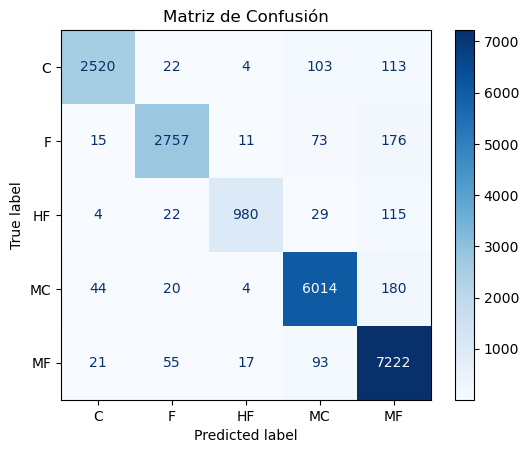

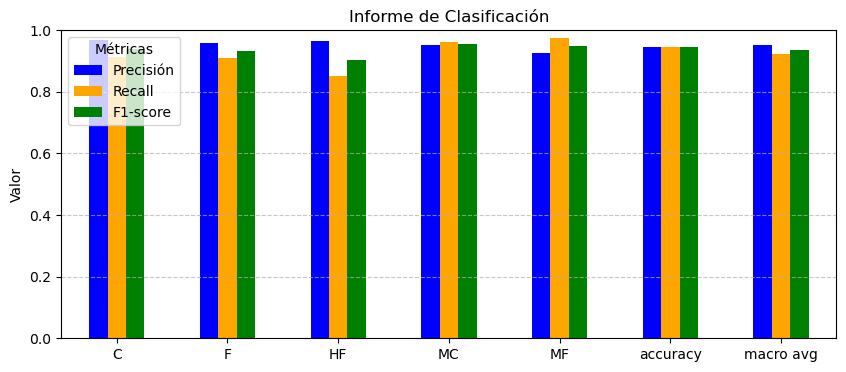

In [ ]:
# Visualización de la matriz de confusión
plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Visualización del informe de clasificación
# Crear un DataFrame para las métricas
metrics_df = pd.DataFrame(report).transpose()

# Seleccionar solo las métricas relevantes
metrics_df = metrics_df.iloc[:-1, :3]  # Ignorar el total

# Graficar las métricas
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])
plt.title('Informe de Clasificación')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.show()

<Figure size 1000x600 with 0 Axes>

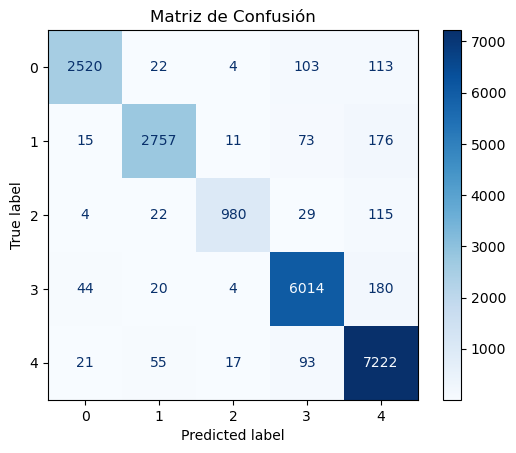

In [ ]:
# class_order = ['C', 'MC', 'MF', 'F', 'HF']
# class_order = ['MC', 'MF', 'F', 'HF']

plt.figure(figsize=(10, 6))
# ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(cmap=plt.cm.Blues)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=plt.cm.Blues)

plt.title('Matriz de Confusión')
plt.show()

<Figure size 1000x600 with 0 Axes>

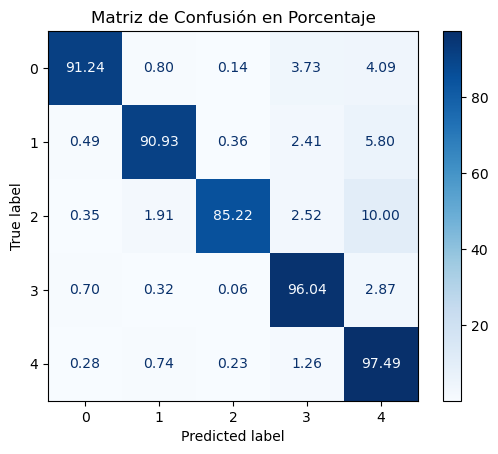

In [ ]:
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_percentage).plot(cmap=plt.cm.Blues, values_format=".2f")
# ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_order).plot(cmap=plt.cm.Blues, values_format=".2f")

plt.title('Matriz de Confusión en Porcentaje')
plt.show()

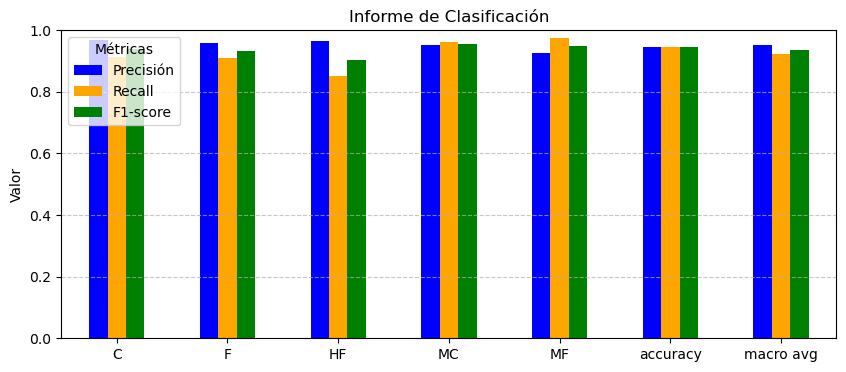

In [ ]:
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])
plt.title('Informe de Clasificación')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.show()

In [ ]:
metrics_df

,precision,recall,f1-score
C,0.967742,0.912382,0.939247
F,0.958623,0.909301,0.933311
HF,0.964567,0.852174,0.904894
MC,0.952788,0.960396,0.956577
MF,0.925186,0.974892,0.949389
accuracy,0.945619,0.945619,0.945619
macro avg,0.953781,0.921829,0.936683


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1. Dividir los datos
# -----------------------------
# Asegúrate de tener X e y definidos previamente


# Codificar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


# -----------------------------
# 2. Optuna con XGBoost (GPU)
# -----------------------------

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        #"subsample": trial.suggest_float("subsample", 0.5, 1.0),  # new
        #"colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # new
        #"gamma": trial.suggest_float("gamma", 0, 5),  # new
        "tree_method": "hist",
        "device": "cuda",
        "eval_metric": "logloss",
    }
    model = xgb.XGBClassifier(**params)
    #score = cross_val_score(model, X_train, y_train, cv=2, scoring="accuracy").mean()
    #print(f"Trial {trial.number} - Accuracy: {score:.4f}")
    #eturn score

    score = cross_val_score(model, X_train, y_train, cv=2, scoring="accuracy").mean()
    print(f"Trial {trial.number} - Precision: {score:.4f}")
    return score


# -----------------------------
# 3. Ejecutar la optimización
# -----------------------------
xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50)

# -----------------------------
# 4. Visualizar progreso
# -----------------------------
plt.figure(figsize=(8, 5))
plot_optimization_history(xgb_study)
plt.title("Progresión del Accuracy por Trial")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plot_param_importances(xgb_study)
plt.title("Importancia de Parámetros")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Entrenar modelo final
# -----------------------------
best_xgb = xgb.XGBClassifier(**xgb_study.best_params)
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)
original_labels = le.inverse_transform(y_pred_xgb)


# -----------------------------
# 6. Evaluar resultados
# -----------------------------

print("Precisión XGBoost:", accuracy_score(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_).plot(cmap=plt.cm.Blues)
plt.title("XGBoost (GPU) - Matriz de Confusión")
plt.show()




[I 2025-03-26 17:52:26,918] A new study created in memory with name: no-name-56ca647b-0047-4b54-a532-352d92b64543


C:\Users\Admin\AppData\Local\Temp\ipykernel_38540\1197259081.py:9: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(xgb_study)
C:\Users\Admin\AppData\Local\Temp\ipykernel_38540\1197259081.py:23: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(xgb_study)


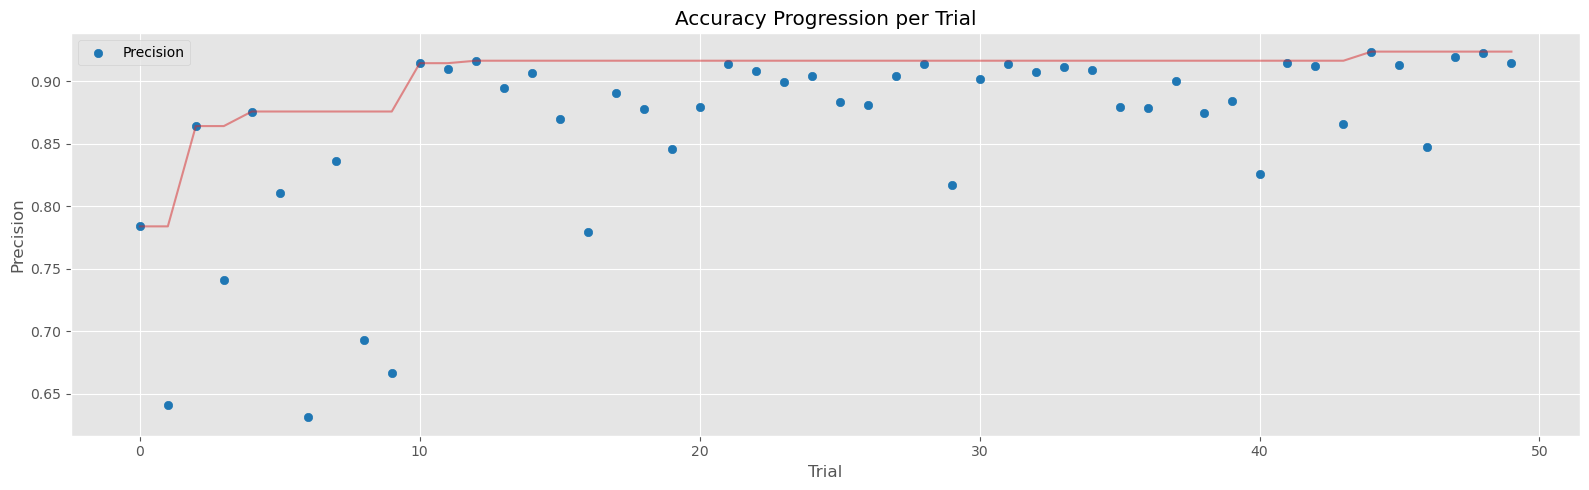

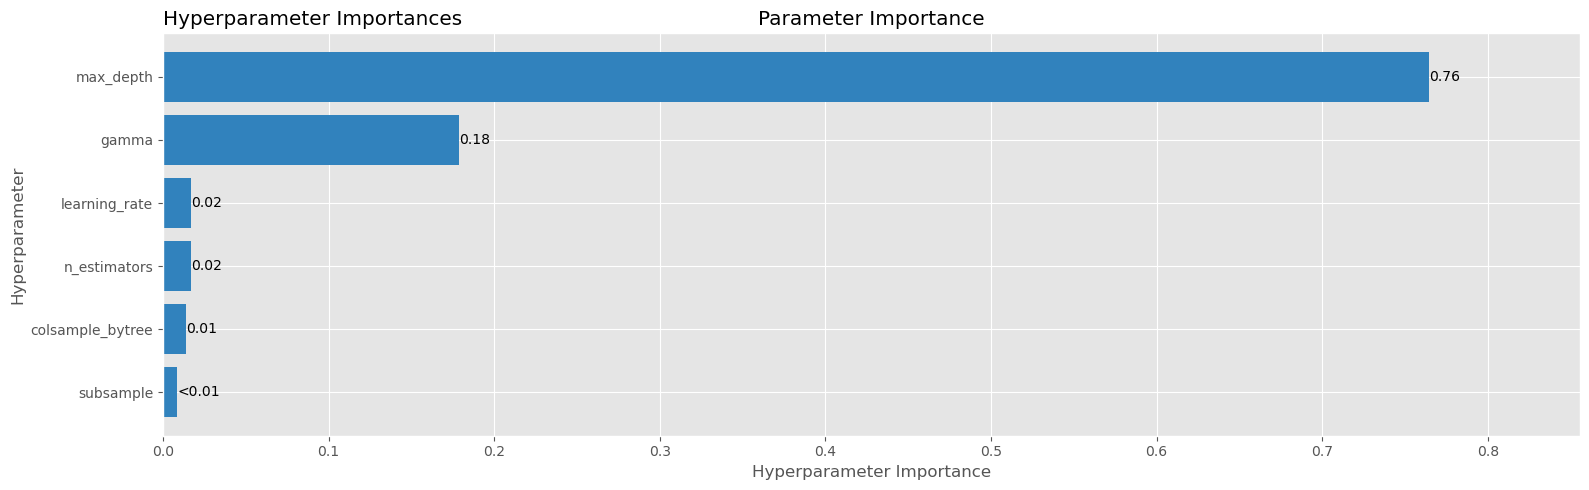

In [ ]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Visualización del progreso de accuracy


# Crear figura manualmente con el tamaño deseado
# Generar gráfico
ax = plot_optimization_history(xgb_study)

# Cambiar tamaño desde la figura asociada al eje
fig = ax.figure
fig.set_size_inches(16, 5)
plt.title("Accuracy Progression per Trial")
plt.ylabel("Precision")  # ← Etiqueta personalizada para el eje Y
plt.grid(True)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Precision"])
plt.tight_layout()
plt.savefig("D:/Investigación/Investigacion-Jorge/accuracy_progression_per_trial.pdf")

# Visualización de importancia de parámetros
ax = plot_param_importances(xgb_study)
fig = ax.figure
fig.set_size_inches(16, 5)

plt.title("Parameter Importance")
plt.grid(True)
# Cambiar texto de la leyenda
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, [""])
ax.get_legend().remove()
plt.tight_layout()
plt.savefig("D:/Investigación/Investigacion-Jorge/parameter_importance.pdf")



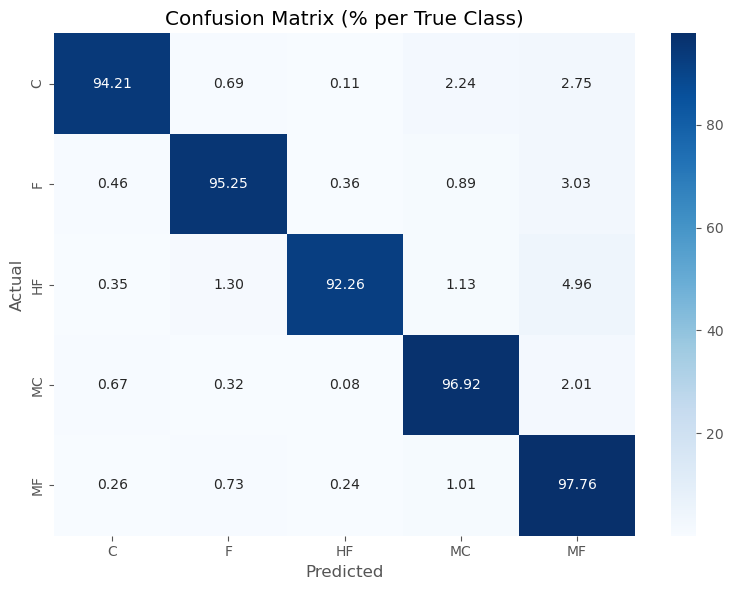

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión en porcentaje
cm_percent = confusion_matrix(y_test, y_pred_xgb, normalize='true') * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (% per True Class)")
plt.tight_layout()

# Guardar en PDF
plt.savefig("D:/Investigación/Investigacion-Jorge/confusion_matrix_percent.pdf")  # <- esta línea guarda el gráfico

plt.show()


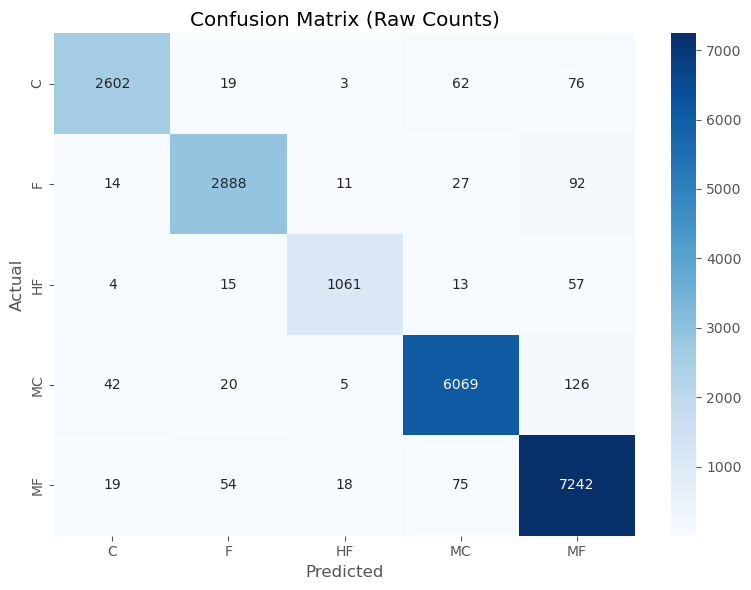

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matriz de confusión con valores reales
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Raw Counts)")
plt.tight_layout()

# Guardar en PDF
plt.savefig("D:/Investigación/Investigacion-Jorge/confusion_matrix_raw.pdf")  # <- esta línea guarda el gráfico

plt.show()


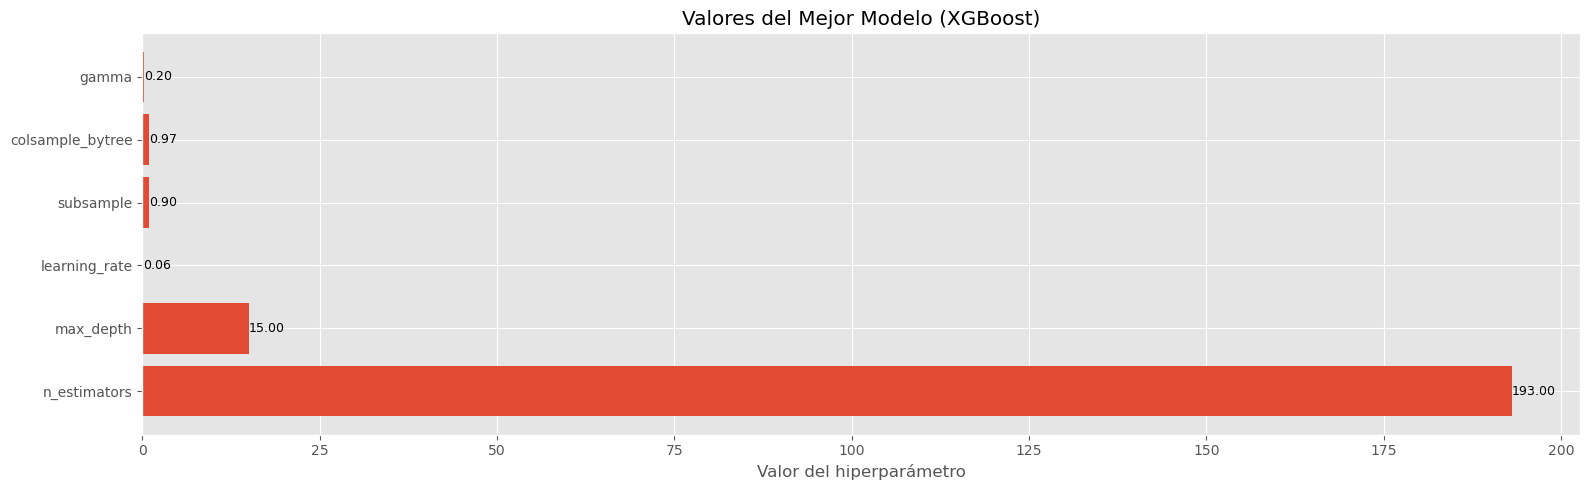

In [ ]:
import matplotlib.pyplot as plt

# Obtener los mejores parámetros
best_params = xgb_study.best_params

# Ordenar para estética (opcional)
params_keys = list(best_params.keys())
params_values = list(best_params.values())

plt.figure(figsize=(16, 5))
bars = plt.barh(params_keys, params_values)
plt.xlabel("Valor del hiperparámetro")
plt.title("Valores del Mejor Modelo (XGBoost)")
plt.grid(True, axis='x')
plt.tight_layout()

# Agregar los valores numéricos al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', ha='left', fontsize=9)

# Guardar en PDF
plt.savefig("D:/Investigación/Investigacion-Jorge/best_model_values.pdf")  # <- Esta línea guarda el gráfico como PDF
plt.show()



In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# -----------------------------
# Reporte de métricas
# -----------------------------
report_dict = classification_report(y_test, y_pred_xgb, target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Redondear a 2 decimales
df_report = df_report.round(2)

# Guardar como CSV
df_report.to_csv("D:/Investigación/Investigacion-Jorge/classification_report_xgboost.csv")

# También mostrar en pantalla si deseas
print("Reporte de Clasificación (XGBoost):\n")
print(df_report)


Reporte de Clasificación (XGBoost):

              precision  recall  f1-score   support
C                  0.97    0.94      0.96   2762.00
F                  0.96    0.95      0.96   3032.00
HF                 0.97    0.92      0.94   1150.00
MC                 0.97    0.97      0.97   6262.00
MF                 0.95    0.98      0.97   7408.00
accuracy           0.96    0.96      0.96      0.96
macro avg          0.97    0.95      0.96  20614.00
weighted avg       0.96    0.96      0.96  20614.00


In [ ]:
!pip install xgboost --upgrade



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# -----------------------------
# 1. Dividir los datos
# -----------------------------
# Asume X, y definidos previamente
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Convertir a formato GPU (cuml necesita cupy o cudf en algunos casos)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# -----------------------------
# 2. Optuna con cuML RandomForest
# -----------------------------
def cuml_rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42,
    }
    model = cuRF(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Trial {trial.number} - Accuracy: {acc:.4f}")
    return acc

# -----------------------------
# 3. Ejecutar optimización
# -----------------------------
rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(cuml_rf_objective, n_trials=30)

# -----------------------------
# 4. Visualizar progreso
# -----------------------------
plot_optimization_history(rf_study)
plt.title("Progresión del Accuracy por Trial (cuML RF)")
plt.tight_layout()
plt.show()

plot_param_importances(rf_study)
plt.title("Importancia de Parámetros (cuML RF)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Entrenar modelo final
# -----------------------------
best_rf = cuRF(**rf_study.best_params)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
original_labels = le.inverse_transform(y_pred_rf)

# -----------------------------
# 6. Evaluar resultados
# -----------------------------
print("Precisión cuML RF (GPU):", accuracy_score(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_).plot(cmap=plt.cm.Blues)
plt.title("cuML Random Forest (GPU) - Matriz de Confusión")
plt.show()


ModuleNotFoundError: No module named 'cuml'

## 2.3. Balanceo del modelo

In [ ]:
# Importar librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
# Asignar las características y el target
X = df_GPR_Dyn[features]  # Sustituir 'features' por tus columnas de características
y = df_GPR_Dyn[target]    # Sustituir 'target' por el nombre de tu columna objetivo

# Eliminar filas con valores NaN
data = pd.concat([X, y], axis=1)  # Combinar X e y temporalmente
data = data.dropna()              # Eliminar filas con valores NaN
X = data[features]                # Recuperar X sin NaN
y = data[target]                  # Recuperar y sin NaN

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicar SMOTE para balancear las clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Crear el modelo de clasificación con ajuste de pesos
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Entrenar el modelo con los datos reequilibrados
model.fit(X_train_resampled, y_train_resampled)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')

# Evaluar el modelo con la matriz de confusión y el reporte de clasificación
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(cm)

report = classification_report(y_test, y_pred, target_names=y.unique())
print("\nReporte de clasificación:")
print(report)

# Opcional: Mostrar las proporciones de las clases antes y después del balanceo
print("\nDistribución de clases antes del balanceo:")
print(y_train.value_counts())

print("\nDistribución de clases después del balanceo (con SMOTE):")
print(pd.Series(y_train_resampled).value_counts())

Precisión del modelo: 0.92

Matriz de confusión:
[[2506   47   51   63   31]
 [  28 2820   98   52   62]
 [  14   20 1110    9   28]
 [  80  103  122 5842  116]
 [  70  208  232  165 6737]]

Reporte de clasificación:
              precision    recall  f1-score   support

          MC       0.93      0.93      0.93      2698
           C       0.88      0.92      0.90      3060
          MF       0.69      0.94      0.79      1181
          HF       0.95      0.93      0.94      6263
           F       0.97      0.91      0.94      7412

    accuracy                           0.92     20614
   macro avg       0.88      0.93      0.90     20614
weighted avg       0.93      0.92      0.92     20614


Distribución de clases antes del balanceo:
Clas_2025_FI_T_Medium
MF    29645
MC    25050
F     12239
C     10794
HF     4724
Name: count, dtype: int64

Distribución de clases después del balanceo (con SMOTE):
Clas_2025_FI_T_Medium
MF    29645
F     29645
MC    29645
HF    29645
C     29645
Na

<Figure size 1000x600 with 0 Axes>

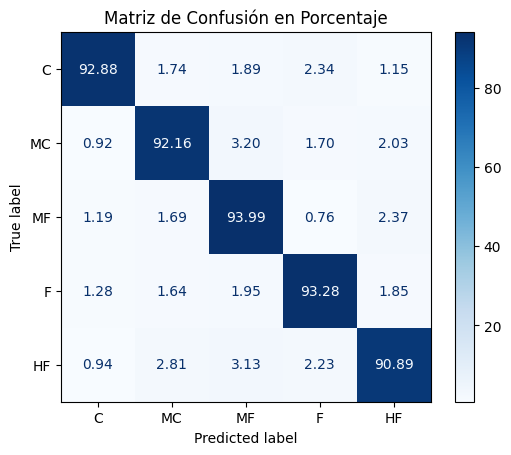

In [ ]:
class_order = ['C', 'MC', 'MF', 'F', 'HF']
# class_order = ['MC', 'MF', 'F', 'HF']

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_order)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")
plt.title('Matriz de Confusión en Porcentaje')
plt.show()

<Figure size 1000x600 with 0 Axes>

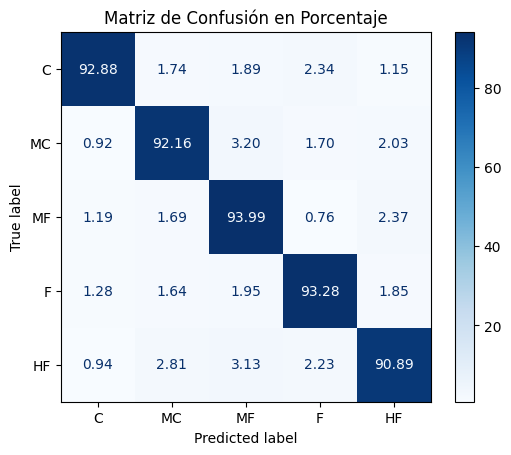

In [ ]:
class_order = ['C', 'MC', 'MF', 'F', 'HF']
# class_order = ['MC', 'MF', 'F', 'HF']

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_order)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")
plt.title('Matriz de Confusión en Porcentaje')
plt.show()

# 3. Hiperparametros

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           verbose=2,
                           n_jobs=-1)

grid_search.fit(X_train_resampled, y_train_resampled)
print("Mejores parámetros:", grid_search.best_params_)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Codificar las etiquetas de la variable objetivo (y) en valores numéricos
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convertir categorías a números

# Actualizar el conjunto de datos después de eliminar NaN
data = pd.concat([X, pd.Series(y_encoded, name="y_encoded")], axis=1)
data = data.dropna()
X = data[features]
y = data["y_encoded"]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicar SMOTE para balancear las clases en el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Crear el modelo de clasificación XGBoost
model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Entrenar el modelo con los datos reequilibrados
model.fit(X_train_resampled, y_train_resampled)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')

# Evaluar el modelo con la matriz de confusión y el reporte de clasificación
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:")
print(cm)

# Decodificar etiquetas para generar el reporte de clasificación
target_names = label_encoder.inverse_transform(range(len(label_encoder.classes_)))
report = classification_report(y_test, y_pred, target_names=target_names)
print("\nReporte de clasificación:")
print(report)

# Opcional: Mostrar las proporciones de las clases antes y después del balanceo
print("\nDistribución de clases antes del balanceo:")
print(pd.Series(y_train).value_counts())

print("\nDistribución de clases después del balanceo (con SMOTE):")
print(pd.Series(y_train_resampled).value_counts())

In [ ]:
STOP

## 2.4. Cambio en la validacion

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
target = 'Clasification_Clasica_Medium'
# target = 'Clasification_Thesis_Medium'


X = df_GPR_Dyn[features]
y = df_GPR_Dyn[target]

# Filtrar los índices válidos (sin valores nulos)
valid_indices = X.index[X.notna().all(axis=1) & y.notna()]
X = X.loc[valid_indices]
y = y.loc[valid_indices]

In [ ]:
X = df_GPR_Dyn[features]
y = df_GPR_Dyn[target]

# Obtener los valores únicos de 'Pk_Original'
unique_pk = df_GPR_Dyn['Pk_Original'].unique()

# Dividir los valores únicos en conjuntos de entrenamiento y prueba
pk_train, pk_test = train_test_split(unique_pk, test_size=0.2, random_state=42)

# Filtrar el DataFrame completo usando los valores únicos seleccionados
train_data = df_GPR_Dyn[df_GPR_Dyn['Pk_Original'].isin(pk_train)]
test_data = df_GPR_Dyn[df_GPR_Dyn['Pk_Original'].isin(pk_test)]

# Separar las características (X) y la variable objetivo (y) en cada conjunto
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Crear el modelo de clasificación (Random Forest)
model = RandomForestClassifier(random_state=42)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')  # Imprimir la precisión

# Evaluar el modelo
cm = confusion_matrix(y_test, y_pred)  # Calcular la matriz de confusión
report = classification_report(y_test, y_pred, output_dict=True)  # Obtener el informe de clasificación

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE  # Importamos SMOTE para el sobremuestreo
from sklearn.impute import SimpleImputer  # Para imputación de valores faltantes

In [ ]:
# Asumiendo que df_GPR_Dyn es tu DataFrame
X = df_GPR_Dyn[features]
y = df_GPR_Dyn[target]

# Imputar valores faltantes en X y en y (si es necesario)
imputer_X = SimpleImputer(strategy='mean')  # Usamos la media para los valores faltantes en X
X_imputed = imputer_X.fit_transform(X)

# En caso de que 'y' tenga valores faltantes, también los imputamos
imputer_y = SimpleImputer(strategy='most_frequent')  # Usamos la moda para 'y'
y_imputed = imputer_y.fit_transform(y.values.reshape(-1, 1)).ravel()  # Convertimos a vector

# Obtener los valores únicos de 'Pk_Original'
unique_pk = df_GPR_Dyn['Pk_Original'].unique()

# Dividir los valores únicos en conjuntos de entrenamiento y prueba
pk_train, pk_test = train_test_split(unique_pk, test_size=0.2, random_state=42)

# Filtrar el DataFrame completo usando los valores únicos seleccionados
train_data = df_GPR_Dyn[df_GPR_Dyn['Pk_Original'].isin(pk_train)]
test_data = df_GPR_Dyn[df_GPR_Dyn['Pk_Original'].isin(pk_test)]

# Separar las características (X) y la variable objetivo (y) en cada conjunto
X_train = X_imputed[train_data.index]
y_train = y_imputed[train_data.index]
X_test = X_imputed[test_data.index]
y_test = y_imputed[test_data.index]

# Crear el modelo de clasificación (Random Forest) con pesos balanceados
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Aplicar SMOTE para balancear las clases en el conjunto de entrenamiento
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Realizar sobremuestreo en los datos de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Entrenar el modelo con los datos balanceados
model.fit(X_train_res, y_train_res)

# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')  # Imprimir la precisión

# Evaluar el modelo con la matriz de confusión y el reporte de clasificación
cm = confusion_matrix(y_test, y_pred)  # Calcular la matriz de confusión
print("Matriz de Confusión:")
print(cm)

# Obtener y mostrar el informe de clasificación
report = classification_report(y_test, y_pred, output_dict=True)
print("Reporte de Clasificación:")
print(report)

In [ ]:
# Definir el orden de las clases
# class_order = ['C', 'MC', 'MF', 'F', 'HF']
class_order = ['MC', 'MF', 'F', 'HF']

# Calcular la matriz de confusión como porcentaje
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Visualización de la matriz de confusión en porcentaje
plt.figure(figsize=(10, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_order)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")

# Personalización del título
plt.title('Matriz de Confusión en Porcentaje')
plt.show()

In [ ]:
# Visualización de la matriz de confusión
plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# Visualización del informe de clasificación
# Crear un DataFrame para las métricas
metrics_df = pd.DataFrame(report).transpose()

# Seleccionar solo las métricas relevantes
metrics_df = metrics_df.iloc[:-1, :3]  # Ignorar el total

# Graficar las métricas
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])
plt.title('Informe de Clasificación')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.show()

In [ ]:
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])

# Personalización del gráfico
plt.title('Informe de Clasificación', fontsize=14)
plt.ylabel('Valor', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Validacion cruzada

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo de Random Forest
# model = RandomForestClassifier(random_state=42)
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Realizar validación cruzada
cv_scores = cross_val_score(model, X_train, y_train, cv=30)  # 10 pliegues

# Imprimir las puntuaciones de la validación cruzada
print(f'Puntuaciones de la validación cruzada: {cv_scores}')
print(f'Precisión media de la validación cruzada: {np.mean(cv_scores):.2f}')  # Imprimir la precisión media

# Ajustar el modelo al conjunto de entrenamiento completo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la precisión en el conjunto de prueba
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo en el conjunto de prueba: {accuracy:.2f}')  # Imprimir la precisión

# Evaluar el modelo
cm = confusion_matrix(y_test, y_pred)  # Calcular la matriz de confusión
report = classification_report(y_test, y_pred, output_dict=True)  # Obtener el informe de clasificación

In [ ]:
feature_importances = model.feature_importances_

# Crear un DataFrame para mostrar las importancias con los nombres de las características
feature_importance_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': feature_importances
}).sort_values(by='Importancia', ascending=False)

# Imprimir la importancia de cada característica
print("Importancia de cada característica:")
print(feature_importance_df)

# Visualización de la importancia de las características Importancia
plt.figure(figsize=(10, 15))
plt.barh(feature_importance_df['Característica'], feature_importance_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de Características en el Modelo de Random Forest')
plt.gca().invert_yaxis()  # Invertir el eje y para mostrar la característica más importante en la parte superior
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Opción alternativa: gráfico de barras
plt.figure(figsize=(10, 3.5))
plt.bar(range(1, 31), cv_scores*100, color='skyblue')
# plt.title('Resultados de Validación Cruzada (10 Pliegues)')
plt.xlabel('Iteration of cross validation')
plt.ylabel('Accuracy (%)')
plt.xticks(range(1, 31))
plt.ylim(0, 100)  # Limitar el eje y entre 0 y 1
plt.xlim(0, 31)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Visualización de la matriz de confusión
plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
metrics_df = pd.DataFrame(report).transpose()

# Seleccionar solo las métricas relevantes
metrics_df = metrics_df.iloc[:-1, :3]  # Ignorar el total

# Graficar las métricas
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])
plt.title('Informe de Clasificación')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.show()

In [ ]:
# Visualización de la matriz de confusión
plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap=plt.cm.Blues)
plt.xlabel('Measurement of the fouling condition')
plt.ylabel('Prediction of fouling condition')
plt.title('Confusion matrix')
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Visualización de la matriz de confusión en porcentajes
plt.figure(figsize=(10, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues, values_format=".2f", colorbar=False)  # Formato para mostrar porcentajes con dos decimales
plt.ylabel('Measurement of the fouling condition')
plt.xlabel('Prediction of fouling condition')
plt.title('Confusion Matrix (in %)')
plt.show()

In [ ]:
metrics_df = pd.DataFrame(report).transpose()

# Seleccionar solo las métricas relevantes
metrics_df = metrics_df.iloc[:-1, :3]  # Ignorar el total

# Graficar las métricas
metrics_df.plot(kind='bar', figsize=(10, 4), color=['blue', 'orange', 'green'])
plt.title('Informe de Clasificación')
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.ylim(0, 1)  # Limitar el eje y entre 0 y 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métricas', loc='upper left', labels=['Precisión', 'Recall', 'F1-score'])
plt.show()

In [ ]:
metrics_df

### Hyperparametros

In [ ]:
#from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Validacion cruzada + hiperparametros optimizados

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo de Random Forest
# model = RandomForestClassifier(random_state=42)
# model = RandomForestClassifier(random_state=42, class_weight='balanced')
model = RandomForestClassifier(
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=144,
    random_state=42,
    class_weight='balanced'
)

# Realizar validación cruzada
cv_scores = cross_val_score(model, X_train, y_train, cv=30)  # 10 pliegues

# Imprimir las puntuaciones de la validación cruzada
print(f'Puntuaciones de la validación cruzada: {cv_scores}')
print(f'Precisión media de la validación cruzada: {np.mean(cv_scores):.2f}')  # Imprimir la precisión media

# Ajustar el modelo al conjunto de entrenamiento completo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la precisión en el conjunto de prueba
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo en el conjunto de prueba: {accuracy:.2f}')  # Imprimir la precisión

# Evaluar el modelo
cm = confusion_matrix(y_test, y_pred)  # Calcular la matriz de confusión
report = classification_report(y_test, y_pred, output_dict=True)  # Obtener el informe de clasificación

In [ ]:
feature_importances = model.feature_importances_

# Crear un DataFrame para mostrar las importancias con los nombres de las características
feature_importance_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': feature_importances
}).sort_values(by='Importancia', ascending=False)

# Imprimir la importancia de cada característica
print("Importancia de cada característica:")
print(feature_importance_df)

# Visualización de la importancia de las características Importancia
plt.figure(figsize=(10, 15))
plt.barh(feature_importance_df['Característica'], feature_importance_df['Importancia'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de Características en el Modelo de Random Forest')
plt.gca().invert_yaxis()  # Invertir el eje y para mostrar la característica más importante en la parte superior
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Opción alternativa: gráfico de barras
plt.figure(figsize=(15, 3.5))
plt.bar(range(1, 31), cv_scores*100, color='skyblue')
plt.title('(c) Cross-Validation whith optimized hyperparameters')
plt.xlabel('Iteration of cross validation')
plt.ylabel('Accuracy (%)')
plt.xticks(range(1, 31))
plt.ylim(0, 100)  # Limitar el eje y entre 0 y 1
plt.xlim(0, 31)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calcula la matriz de confusión y convierte a porcentaje
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_percentage = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Visualiza la matriz de confusión en porcentaje usando un mapa de calor
plt.figure(figsize=(6.5, 3.2))
sns.heatmap(conf_matrix_percentage, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=['Cas 1', 'Cas 2', 'Cas 3', 'Cas 4'],
            yticklabels=['Cas 1', 'Cas 2', 'Cas 3', 'Cas 4'],
           vmin = 0, vmax = 100)
plt.ylabel('Measurement of the fouling condition')
plt.xlabel('Prediction of fouling condition')
plt.title('(b) Confusion Matrix (in %)')
plt.show()